In [1]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

In [2]:
import pandas as pd
import numpy as np
from matplotlib import pyplot as plt
import os
import seaborn as sns
import sys
import glob
import tqdm
sys.path.append("/extdata4/baeklab/Hyeonseo/m6A/modformer")
from utils import utils

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 2})

## Load Data

In [3]:
hela_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0091_m6Afinal/pileup_strid.genomic.pkl"
hela_genomic_df = pd.read_pickle(hela_genomic_df)
hela_genomic_df = hela_genomic_df[hela_genomic_df["count_all"] >= 20]
print(hela_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1  0.013391   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1 -0.000000   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1 -0.000000   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.012365   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1 -0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1  0.064984   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1 -0.000000   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1 -0.000000   

           

In [4]:
hek_genomic_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.genomic.pkl"
hek_genomic_df = pd.read_pickle(hek_genomic_df)
hek_genomic_df = hek_genomic_df[hek_genomic_df["count_all"] >= 20]
print(hek_genomic_df)

                       genome_id gene_symbol  coding  isoforms      pm6a  \
genome_id                                                                  
chr10:+:1000681  chr10:+:1000681      GTPBP4    True         1 -0.000000   
chr10:+:1000683  chr10:+:1000683      GTPBP4    True         1  0.008392   
chr10:+:1000685  chr10:+:1000685      GTPBP4    True         1  0.007436   
chr10:+:1000694  chr10:+:1000694      GTPBP4    True         1 -0.000000   
chr10:+:1000701  chr10:+:1000701      GTPBP4    True         1  0.016405   
...                          ...         ...     ...       ...       ...   
chrX:-:8732088    chrX:-:8732088       ANOS1    True         1  0.000000   
chrX:-:8732091    chrX:-:8732091       ANOS1    True         1 -0.000000   
chrX:-:8732104    chrX:-:8732104       ANOS1    True         1  0.039769   
chrX:-:8732109    chrX:-:8732109       ANOS1    True         1 -0.000000   
chrX:-:8732112    chrX:-:8732112       ANOS1    True         1  0.048285   

           

In [5]:
hela_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0091_m6Afinal/pileup_strid.npz"
with np.load(hela_df, allow_pickle=True) as data:
    hela_df = pd.DataFrame({key: data[key] for key in data.keys()})
hela_df = hela_df[hela_df["count_all"] >= 20]
print(hela_df)

                 label_id      pm6a       dom  count_all  count_pos  \
2          NM_001080497:2 -0.000000  0.000410         37          0   
6          NM_001277068:2 -0.000000  0.010288         40          0   
8             NM_006287:2  0.033872  0.007615        139          1   
10         NM_001282466:2  1.581740  0.390196         43         15   
13            NM_003937:2 -0.000000  0.014001         66          0   
...                   ...       ...       ...        ...        ...   
28590027  NR_002728:82892  0.000000  0.000000         41          0   
28590028  NR_002728:82895 -0.000000  0.001111         40          0   
28590029  NR_002728:82897  0.000000  0.000000         41          0   
28590030  NR_002728:82900  0.000000  0.000000         41          0   
28590031  NR_002728:82902  0.000000  0.000000         41          0   

          kl_div_neg  kl_div_pos  logsum_1_p_pos  
2          34.551167    0.014187        0.000000  
6          34.302940    0.356586        0.000

In [6]:
hek_df = "/extdata4/baeklab/Hyeonseo/m6A/inference/pileup/AIRNA-DW-v4-m6A_ON0118-20241129-120647-8-182000-token_normalise_ver161024_ON0090_m6Afinal/pileup_strid.npz"
with np.load(hek_df, allow_pickle=True) as data:
    hek_df = pd.DataFrame({key: data[key] for key in data.keys()})
hek_df = hek_df[hek_df["count_all"] >= 20]
print(hek_df)

                 label_id      pm6a       dom  count_all  count_pos  \
1             NM_024682:0  0.112134  0.066583         36          1   
6             NM_198573:2 -0.000000  0.079991         35          0   
7             NM_004134:2  0.026632  0.007007        132          1   
10            NM_139279:2  0.000000  0.000000         25          0   
13            NM_004586:2 -0.000000  0.015743         39          0   
...                   ...       ...       ...        ...        ...   
33284064  NR_002728:65819 -0.000000  0.002020        112          0   
33284065  NR_002728:65820 -0.000000  0.001259        109          0   
33284066  NR_002728:65821 -0.000000  0.000012        101          0   
33284067  NR_002728:65822  0.000000  0.000000         87          0   
33284068  NR_002728:65823  0.000000  0.000000         74          0   

          kl_div_neg  kl_div_pos  logsum_1_p_pos  
1          24.974754    1.781520       -2.142887  
6          22.751352    1.978130        0.000

In [7]:
hek_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.agg.all5mer.pkl")
hela_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.eTAM..v2Genomic.GP3.depth5_None.twm6astrict.agg.all5mer.pkl")

In [8]:
print(hek_label)

                genome_id   5mer  drach  m6A_level  label  depth
0         chr10:+:1000681  GTAGA  False        0.0      0    505
1         chr10:+:1000683  AGACA   True        0.0      0    505
2         chr10:+:1000685  ACACT  False        0.0      0    506
3         chr10:+:1000694  GGATC  False        0.0     -1    505
4         chr10:+:1000701  GGACC   True        0.0      0    505
...                   ...    ...    ...        ...    ...    ...
13247783   chrX:-:9760794  GGATT  False        0.0     -3      6
13247784   chrX:-:9760797  TTAGG  False        0.0     -3      6
13247785   chrX:-:9760808  CCACC  False        0.0     -3      6
13247786   chrX:-:9760817  TGATC  False        0.0     -3      6
13247787   chrX:-:9760823  GTATG  False        0.0     -3      6

[13247788 rows x 6 columns]


In [23]:
print(hek_label["depth"].sum())

2744848159


In [25]:
print(hek_transcript_label["depth"].sum())

2744848159


In [9]:
hek_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/label/BaeklabFinal.Genome.v2Genomic.GP3.depth5_None.twm6astrict.pkl")
hela_transcript_label = pd.read_pickle(
    "/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0091/ON0091/label/BaeklabFinal.eTAM..v2Genomic.GP3.depth5_None.twm6astrict.pkl")

In [10]:
hek_dorado_df = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/runs/exp_MRNA/ON0090/ON0090/result/dorado-070-aligned/intermediates/dorado_output.pkl.m6A.genomic.pkl")
print(hek_dorado_df)

                       genome_id gene_symbol       dom  count_dom  coding
genome_id                                                                
chr10:+:1000680  chr10:+:1000680      GTPBP4  0.142857          7    True
chr10:+:1000681  chr10:+:1000681      GTPBP4  0.004219        474    True
chr10:+:1000683  chr10:+:1000683      GTPBP4  0.004073        491    True
chr10:+:1000685  chr10:+:1000685      GTPBP4  0.017167        466    True
chr10:+:1000688  chr10:+:1000688      GTPBP4  1.000000          1    True
...                          ...         ...       ...        ...     ...
chrX:-:9760794    chrX:-:9760794      GPR143  0.000000          5    True
chrX:-:9760797    chrX:-:9760797      GPR143  0.000000          5    True
chrX:-:9760808    chrX:-:9760808      GPR143  0.250000          4    True
chrX:-:9760817    chrX:-:9760817      GPR143  0.000000          5    True
chrX:-:9760823    chrX:-:9760823      GPR143  0.000000          4    True

[22959784 rows x 5 columns]


In [11]:
fdr_threshold = 0.50

hela_genomic_df_m6a = hela_genomic_df[hela_genomic_df["pm6a"] > fdr_threshold].copy()
hek_genomic_df_m6a = hek_genomic_df[hek_genomic_df["pm6a"] > fdr_threshold].copy()

In [12]:
dorado_f1_threshold = 0.46

airna_arr = hek_genomic_df[(hek_genomic_df["pm6a"] >= fdr_threshold) & (hek_genomic_df["count_all"] >= 20)]["genome_id"].unique()
dorado_arr = hek_dorado_df[(hek_dorado_df["dom"] >= dorado_f1_threshold) & (hek_dorado_df["count_dom"] >= 20)]["genome_id"].unique()

## Venn

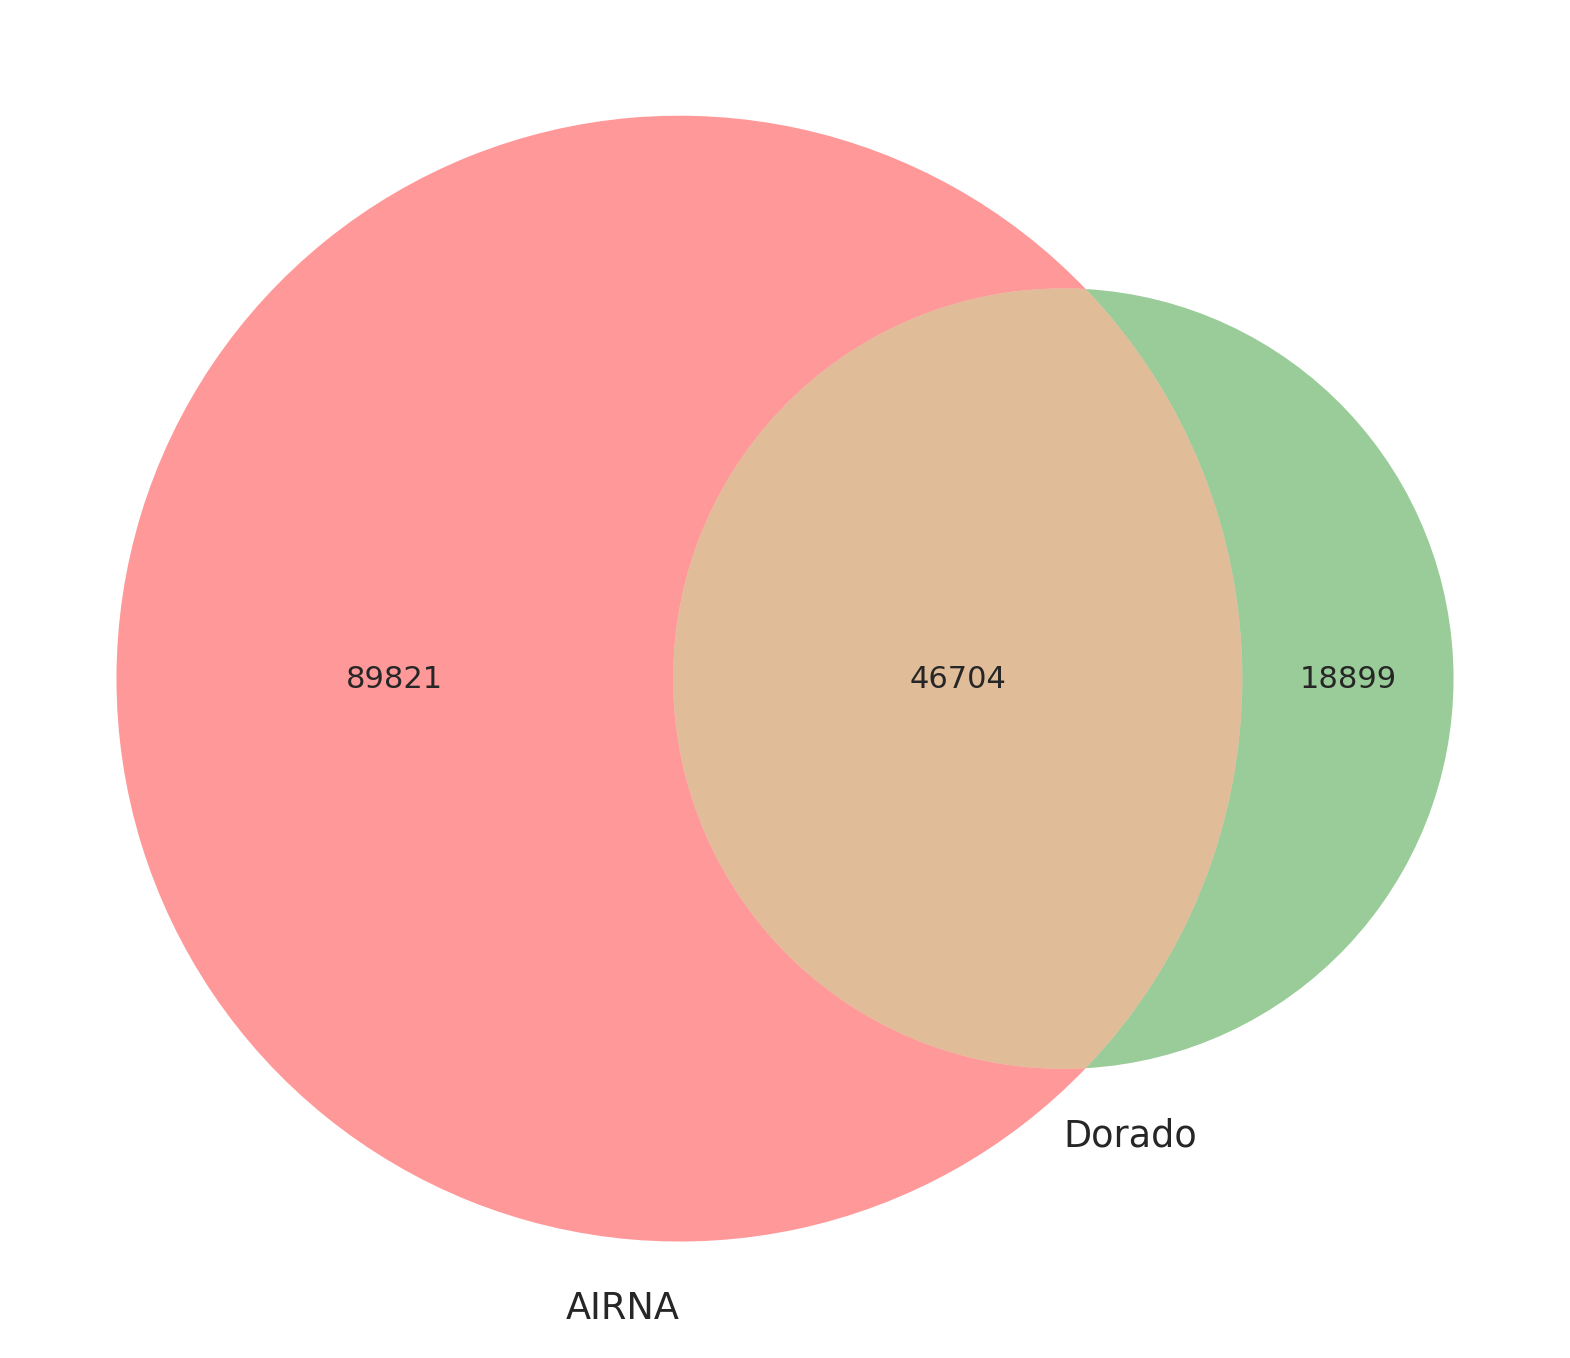

In [13]:
## Plot Venn
import matplotlib_venn as venn
fig, ax = plt.subplots(1, 1, figsize=(20, 20))
## count
venn.venn2([set(airna_arr), set(dorado_arr)], set_labels=("AIRNA", "Dorado"))

plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/venn.pdf", format="pdf")
plt.show()


## Pie

In [14]:
print(hek_label)

                genome_id   5mer  drach  m6A_level  label  depth
0         chr10:+:1000681  GTAGA  False        0.0      0    505
1         chr10:+:1000683  AGACA   True        0.0      0    505
2         chr10:+:1000685  ACACT  False        0.0      0    506
3         chr10:+:1000694  GGATC  False        0.0     -1    505
4         chr10:+:1000701  GGACC   True        0.0      0    505
...                   ...    ...    ...        ...    ...    ...
13247783   chrX:-:9760794  GGATT  False        0.0     -3      6
13247784   chrX:-:9760797  TTAGG  False        0.0     -3      6
13247785   chrX:-:9760808  CCACC  False        0.0     -3      6
13247786   chrX:-:9760817  TGATC  False        0.0     -3      6
13247787   chrX:-:9760823  GTATG  False        0.0     -3      6

[13247788 rows x 6 columns]


In [26]:
hek_eval = hek_genomic_df_m6a.reset_index(drop=True).merge(hek_label, on="genome_id", how="left").dropna()
hela_eval = hela_genomic_df_m6a.reset_index(drop=True).merge(hela_label, on="genome_id", how="left").dropna()

In [89]:
hek_eval = hek_genomic_df_m6a.reset_index(drop=True).merge(hek_label, on="genome_id", how="left")
print(hek_eval[hek_eval["drach"].isna()])

               genome_id gene_symbol  coding  isoforms      pm6a      dom  \
78606   chr22:+:46242324       PPARA    True         5  0.588339  0.10440   
136352   chrX:-:72272137       RPS4X    True         1  1.968870  0.47389   

        count_all  logsum_1_p_pos  kl_div_pos  kl_div_neg 5mer drach  \
78606          23       -7.291876     1.99893   17.147831  NaN   NaN   
136352         20      -27.574249     8.77157    9.738153  NaN   NaN   

        m6A_level  label  depth  
78606         NaN    NaN    NaN  
136352        NaN    NaN    NaN  


In [27]:
print(len(hek_eval), len(hela_eval))

136523 116713


In [91]:
print(hek_df[hek_df["refseq"]=="NM_001007"])

                label_id      pm6a       dom  count_all  count_pos  \
12807        NM_001007:7  0.022591  0.033346        778          4   
28830       NM_001007:13  0.004169  0.017431        878          1   
44094       NM_001007:18 -0.000000  0.002134       1821          0   
47734       NM_001007:19  0.015942  0.014296       2526          9   
53512       NM_001007:21  0.021544  0.015272       5033         24   
...                  ...       ...       ...        ...        ...   
10467178  NM_001007:1358  0.000000  0.000000         22          0   
10473081  NM_001007:1359  0.000000  0.000000         21          0   
10624918  NM_001007:1377  1.968870  0.473890         20          9   
10655697  NM_001007:1381 -0.000000  0.023756         20          0   
10726638  NM_001007:1390  0.000000  0.000000         20          0   

           kl_div_neg  kl_div_pos  logsum_1_p_pos     refseq   pos  
12807      554.655151   19.133739       -9.066006  NM_001007     7  
28830      725.482483

113591 6635 15173 1124
[0.8320283  0.04859987 0.11113878 0.00823304]


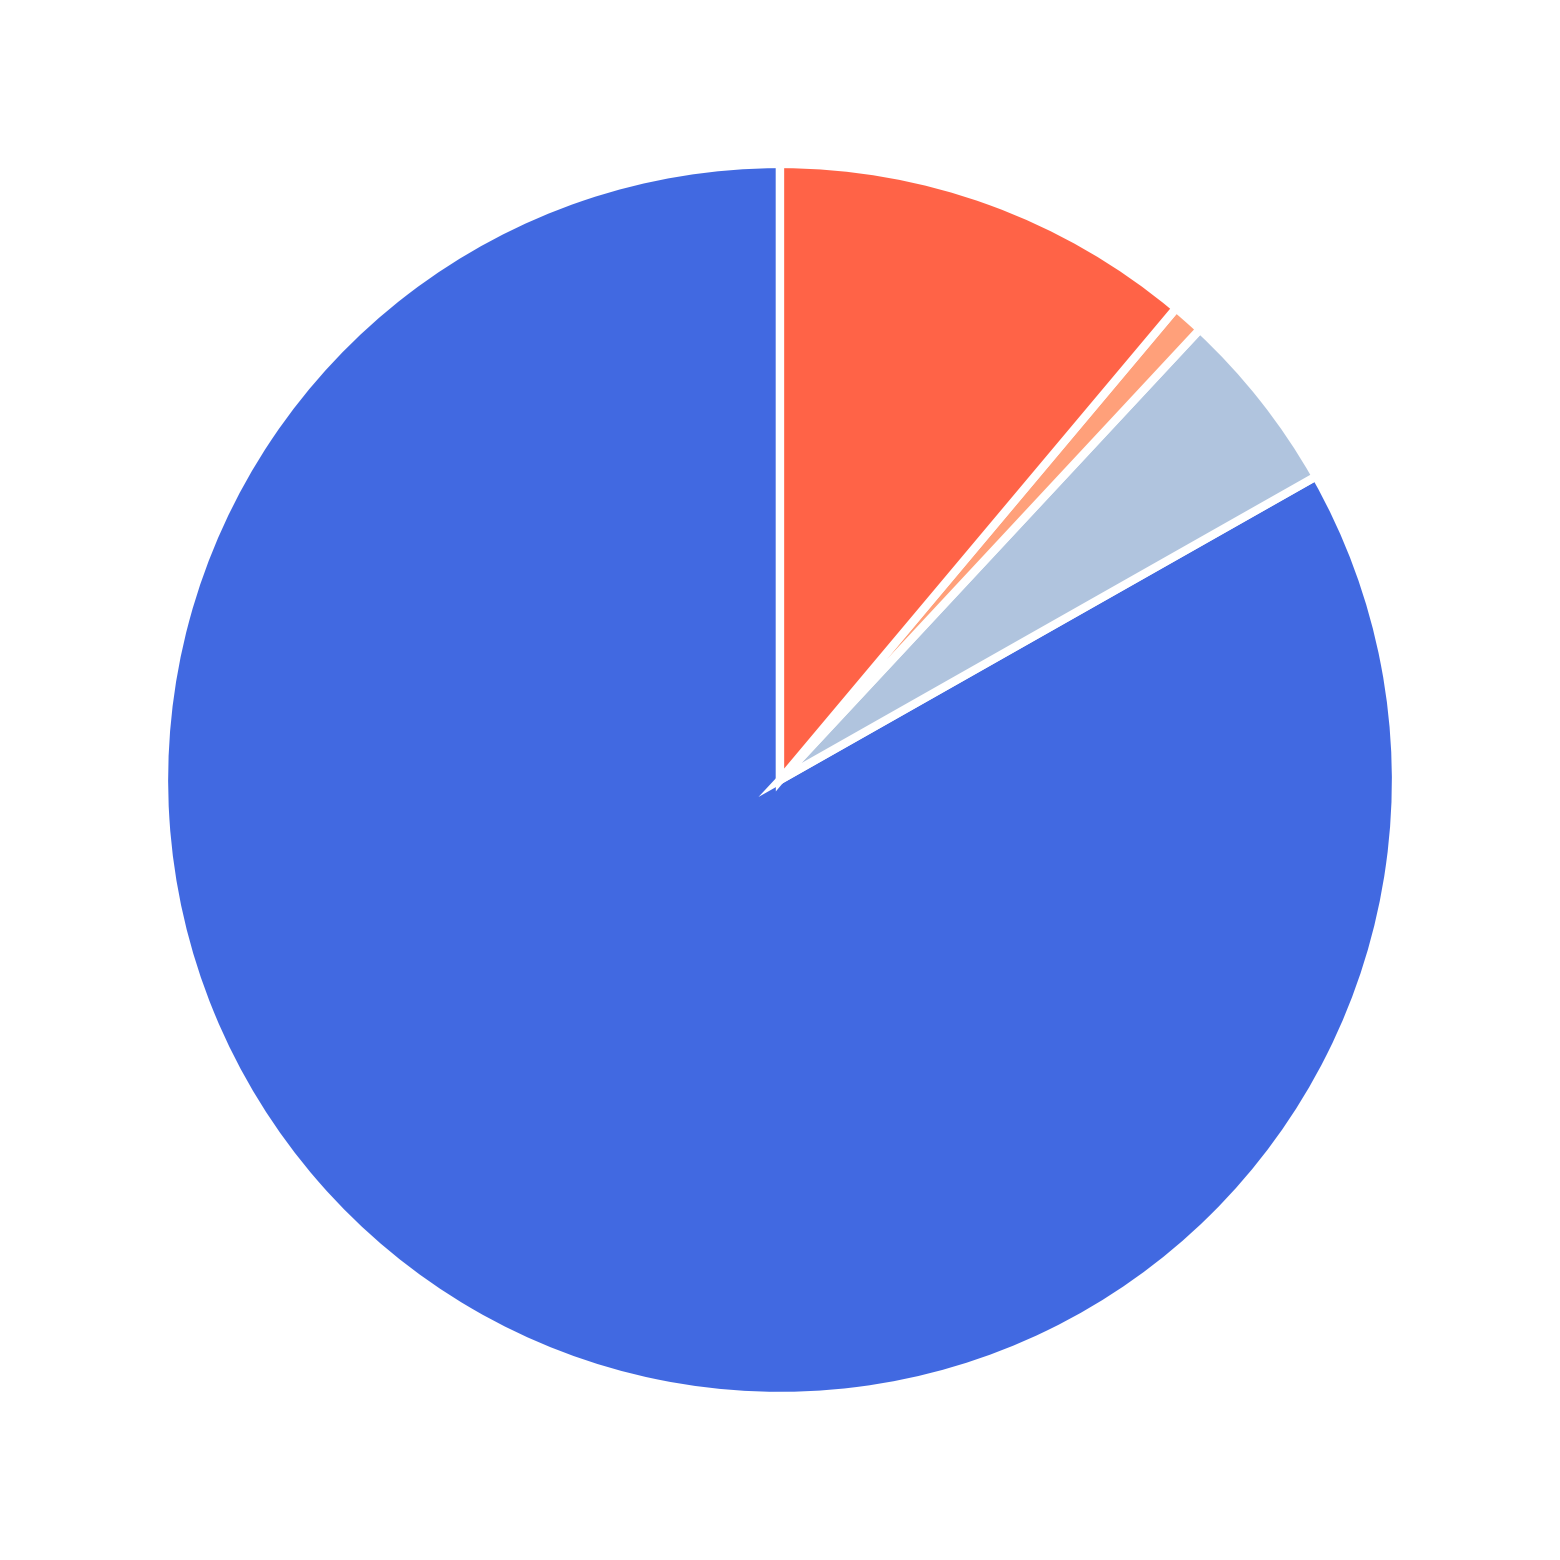

In [28]:
m6a_df = hek_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HEK.pdf", format="pdf")
plt.show()


97423 5433 12914 943
[0.83472278 0.04655008 0.11064749 0.00807965]


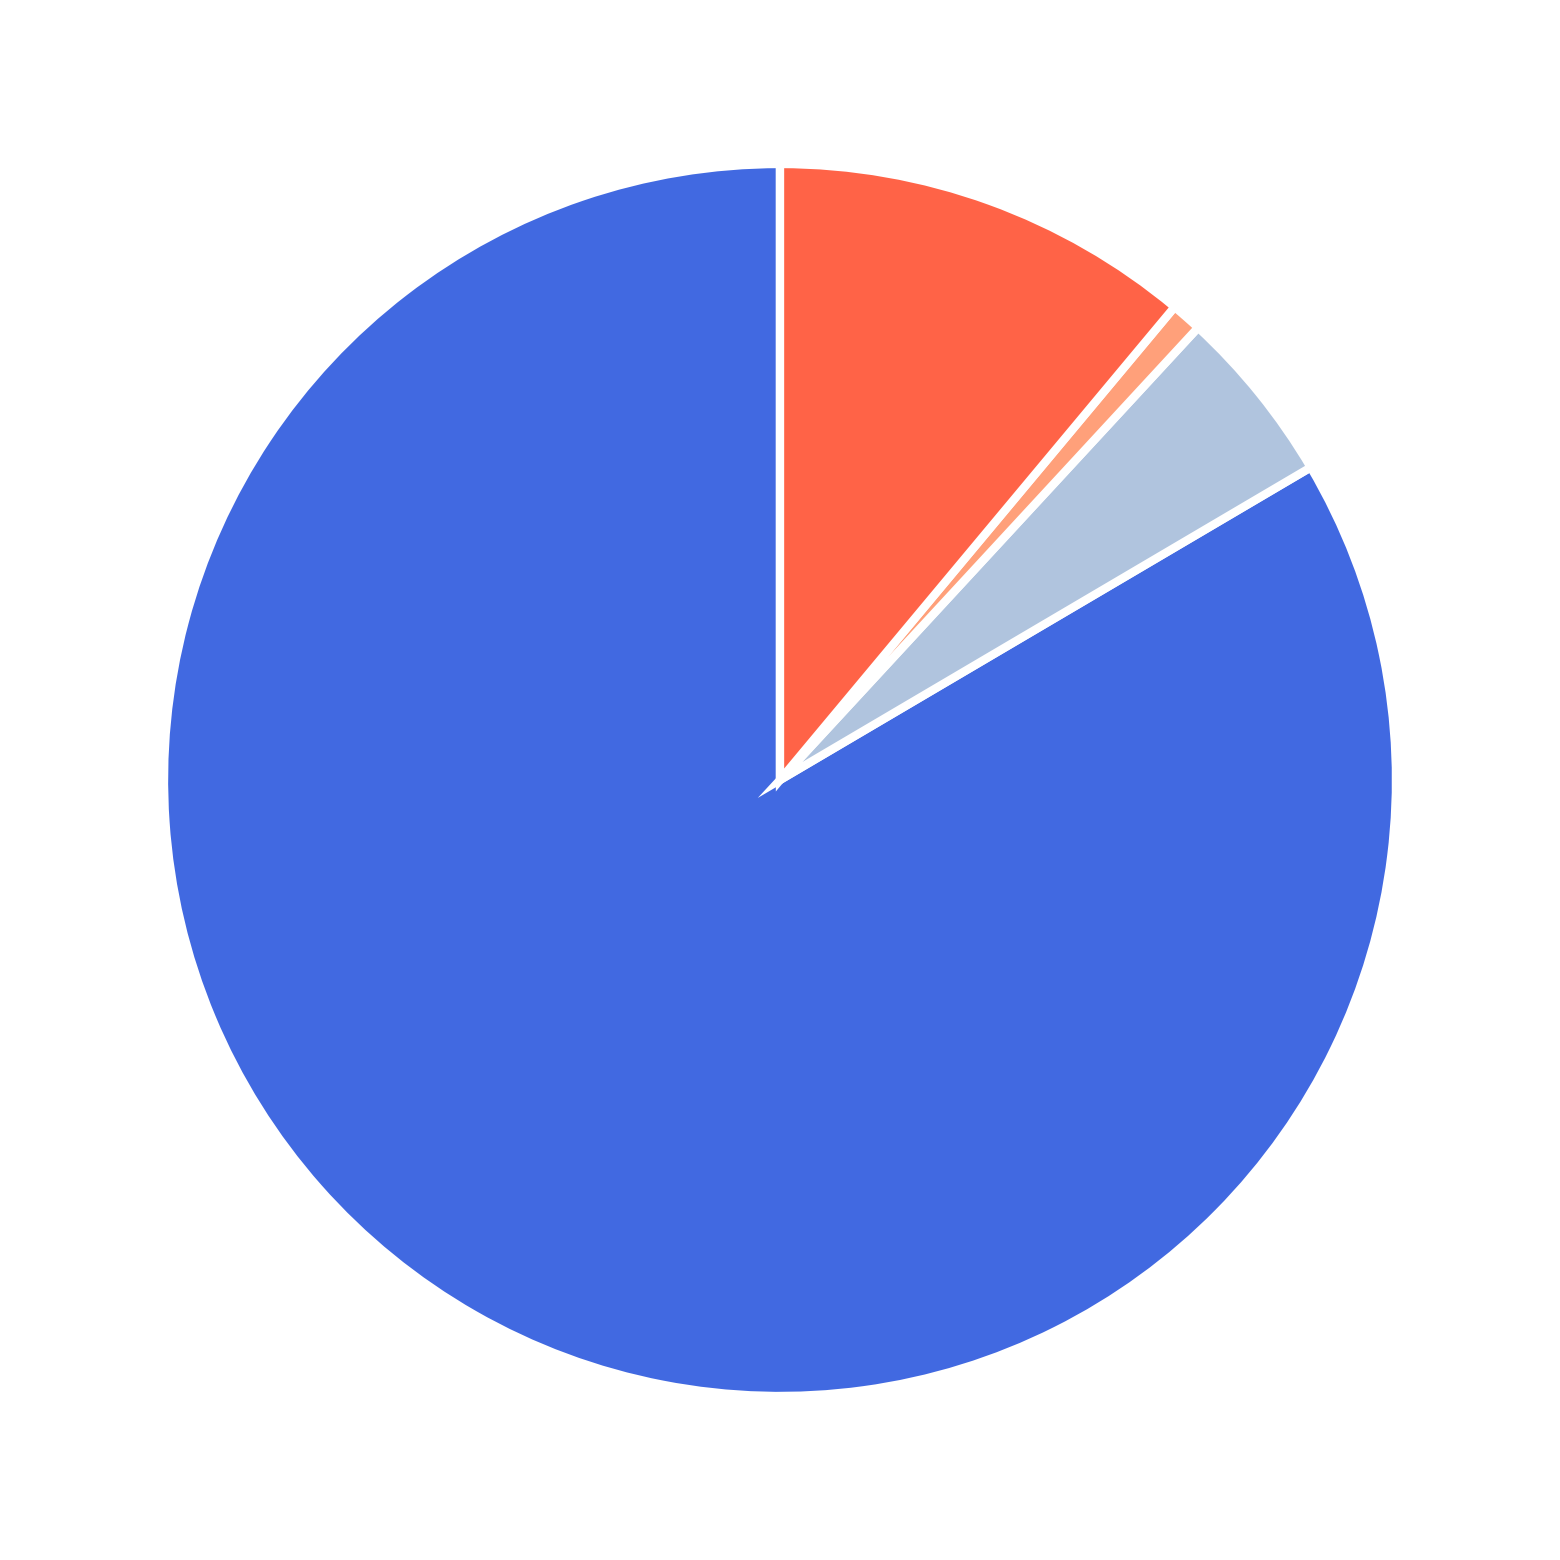

In [29]:
m6a_df = hela_eval
drach_coding = len(m6a_df[(m6a_df["drach"]) & (m6a_df["coding"])])
drach_noncoding = len(m6a_df[(m6a_df["drach"]) & (~m6a_df["coding"])])
non_drach_coding = len(m6a_df[(~m6a_df["drach"]) & (m6a_df["coding"])])
non_drach_noncoding = len(m6a_df[(~m6a_df["drach"]) & (~m6a_df["coding"])])

print(drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding)
print(np.array([drach_coding, drach_noncoding, non_drach_coding, non_drach_noncoding, ])/len(m6a_df))

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
y = [drach_coding, drach_noncoding, non_drach_noncoding, non_drach_coding, ]
plt.rcParams.update({'font.size': 32, 'lines.linewidth': 6})
wp = {'linewidth': 6, 'edgecolor':'white'}
colors = ['royalblue', 'lightsteelblue', 'lightsalmon', 'tomato', ]
plt.pie(y,startangle = 90, colors=colors, wedgeprops=wp)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/pie_HeLa.pdf", format="pdf")
plt.show()
        

## 5mer motif

In [30]:
hek_eval_5mer = hek_eval.copy()
hek_eval_5mer["5mer"] = hek_eval_5mer["5mer"].str.split(":")
hek_eval_5mer = hek_eval_5mer.explode("5mer")
print(hek_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100360903         SCD    True         1  0.567159  0.097964   
1       chr10:+:100363097         SCD    True         1  0.870893  0.182981   
2       chr10:+:100363423         SCD    True         1  0.775987  0.255271   
3       chr10:+:100364038         SCD    True         1  0.534350  0.118845   
4       chr10:+:100364512         SCD    True         1  1.594018  0.353046   
...                   ...         ...     ...       ...       ...       ...   
136520    chrX:-:85864679         CHM    True         2  2.515470  0.577877   
136521    chrX:-:85864735         CHM    True         2  0.666557  0.161439   
136522    chrX:-:85956342         CHM    True         1  0.812354  0.189373   
136523    chrX:-:85971260         CHM    True         1  1.967544  0.527948   
136524    chrX:-:85971360         CHM    True         1  0.735561  0.202630   

        count_all  logsum_1_p_pos  kl_div_pos   kl_

In [31]:
hela_eval_5mer = hela_eval.copy()
hela_eval_5mer["5mer"] = hela_eval_5mer["5mer"].str.split(":")
hela_eval_5mer = hela_eval_5mer.explode("5mer")
print(hela_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100360903         SCD    True         1  0.544819  0.089941   
1       chr10:+:100363097         SCD    True         1  0.687378  0.143955   
2       chr10:+:100363423         SCD    True         1  0.709202  0.212308   
3       chr10:+:100364512         SCD    True         1  1.434435  0.305240   
4       chr10:+:100364569         SCD    True         1  0.773057  0.168563   
...                   ...         ...     ...       ...       ...       ...   
116709    chrX:-:85956342         CHM    True         2  1.036226  0.217966   
116710    chrX:-:85963898         CHM    True         1  0.575107  0.105076   
116711    chrX:-:85971349         CHM    True         1  0.557227  0.109909   
116712    chrX:-:85971356         CHM    True         1  0.604555  0.138024   
116713    chrX:-:85971360         CHM    True         1  0.731550  0.231307   

        count_all  logsum_1_p_pos   kl_div_pos   kl

In [32]:
def drach_ed(seq):
    ed = 0
    if not seq[0] in ["A", "G", "T", "U"]:
        ed += 1
    if not seq[1] in ["G", "A"]:
        ed += 1
    if not seq[2] == "A":
        ed += 1
    if not seq[3] == "C":
        ed += 1
    if not seq[4] in ["A", "C", "T", "U"]:
        ed += 1
    return ed


In [33]:
hek_eval_5mer["drach_ed"] = hek_eval_5mer["5mer"].apply(drach_ed)
print(hek_eval_5mer)

                genome_id gene_symbol  coding  isoforms      pm6a       dom  \
0       chr10:+:100360903         SCD    True         1  0.567159  0.097964   
1       chr10:+:100363097         SCD    True         1  0.870893  0.182981   
2       chr10:+:100363423         SCD    True         1  0.775987  0.255271   
3       chr10:+:100364038         SCD    True         1  0.534350  0.118845   
4       chr10:+:100364512         SCD    True         1  1.594018  0.353046   
...                   ...         ...     ...       ...       ...       ...   
136520    chrX:-:85864679         CHM    True         2  2.515470  0.577877   
136521    chrX:-:85864735         CHM    True         2  0.666557  0.161439   
136522    chrX:-:85956342         CHM    True         1  0.812354  0.189373   
136523    chrX:-:85971260         CHM    True         1  1.967544  0.527948   
136524    chrX:-:85971360         CHM    True         1  0.735561  0.202630   

        count_all  logsum_1_p_pos  kl_div_pos   kl_

In [34]:
print(hek_eval_5mer["drach_ed"].value_counts())

drach_ed
0    120233
1     15341
2       724
3       243
4        71
Name: count, dtype: int64


In [35]:
print(hek_eval_5mer[hek_eval_5mer["drach_ed"] == 4]["5mer"].value_counts())

5mer
CCATG    49
CCAGG    15
CTATG     4
CTAAG     1
CCAAG     1
CTAGG     1
Name: count, dtype: int64


In [36]:
import re

     5mer  count
0   GGACT  20070
1   GGACA  16462
2   GAACT  13759
3   AGACT  13648
4   GGACC  11197
5   TGACT   9874
6   AAACT   8642
7   AGACA   6482
8   GAACA   5622
9   GGACG   4364
10  AGACC   3063
11  TGACA   2841
12  GAACC   2630
13  GGATT   2575
14  TAACT   2175
15  AAACA   1718
16  GTACT   1351
17  TGACC   1039
18  AGACG   1004
19  AAACC    738


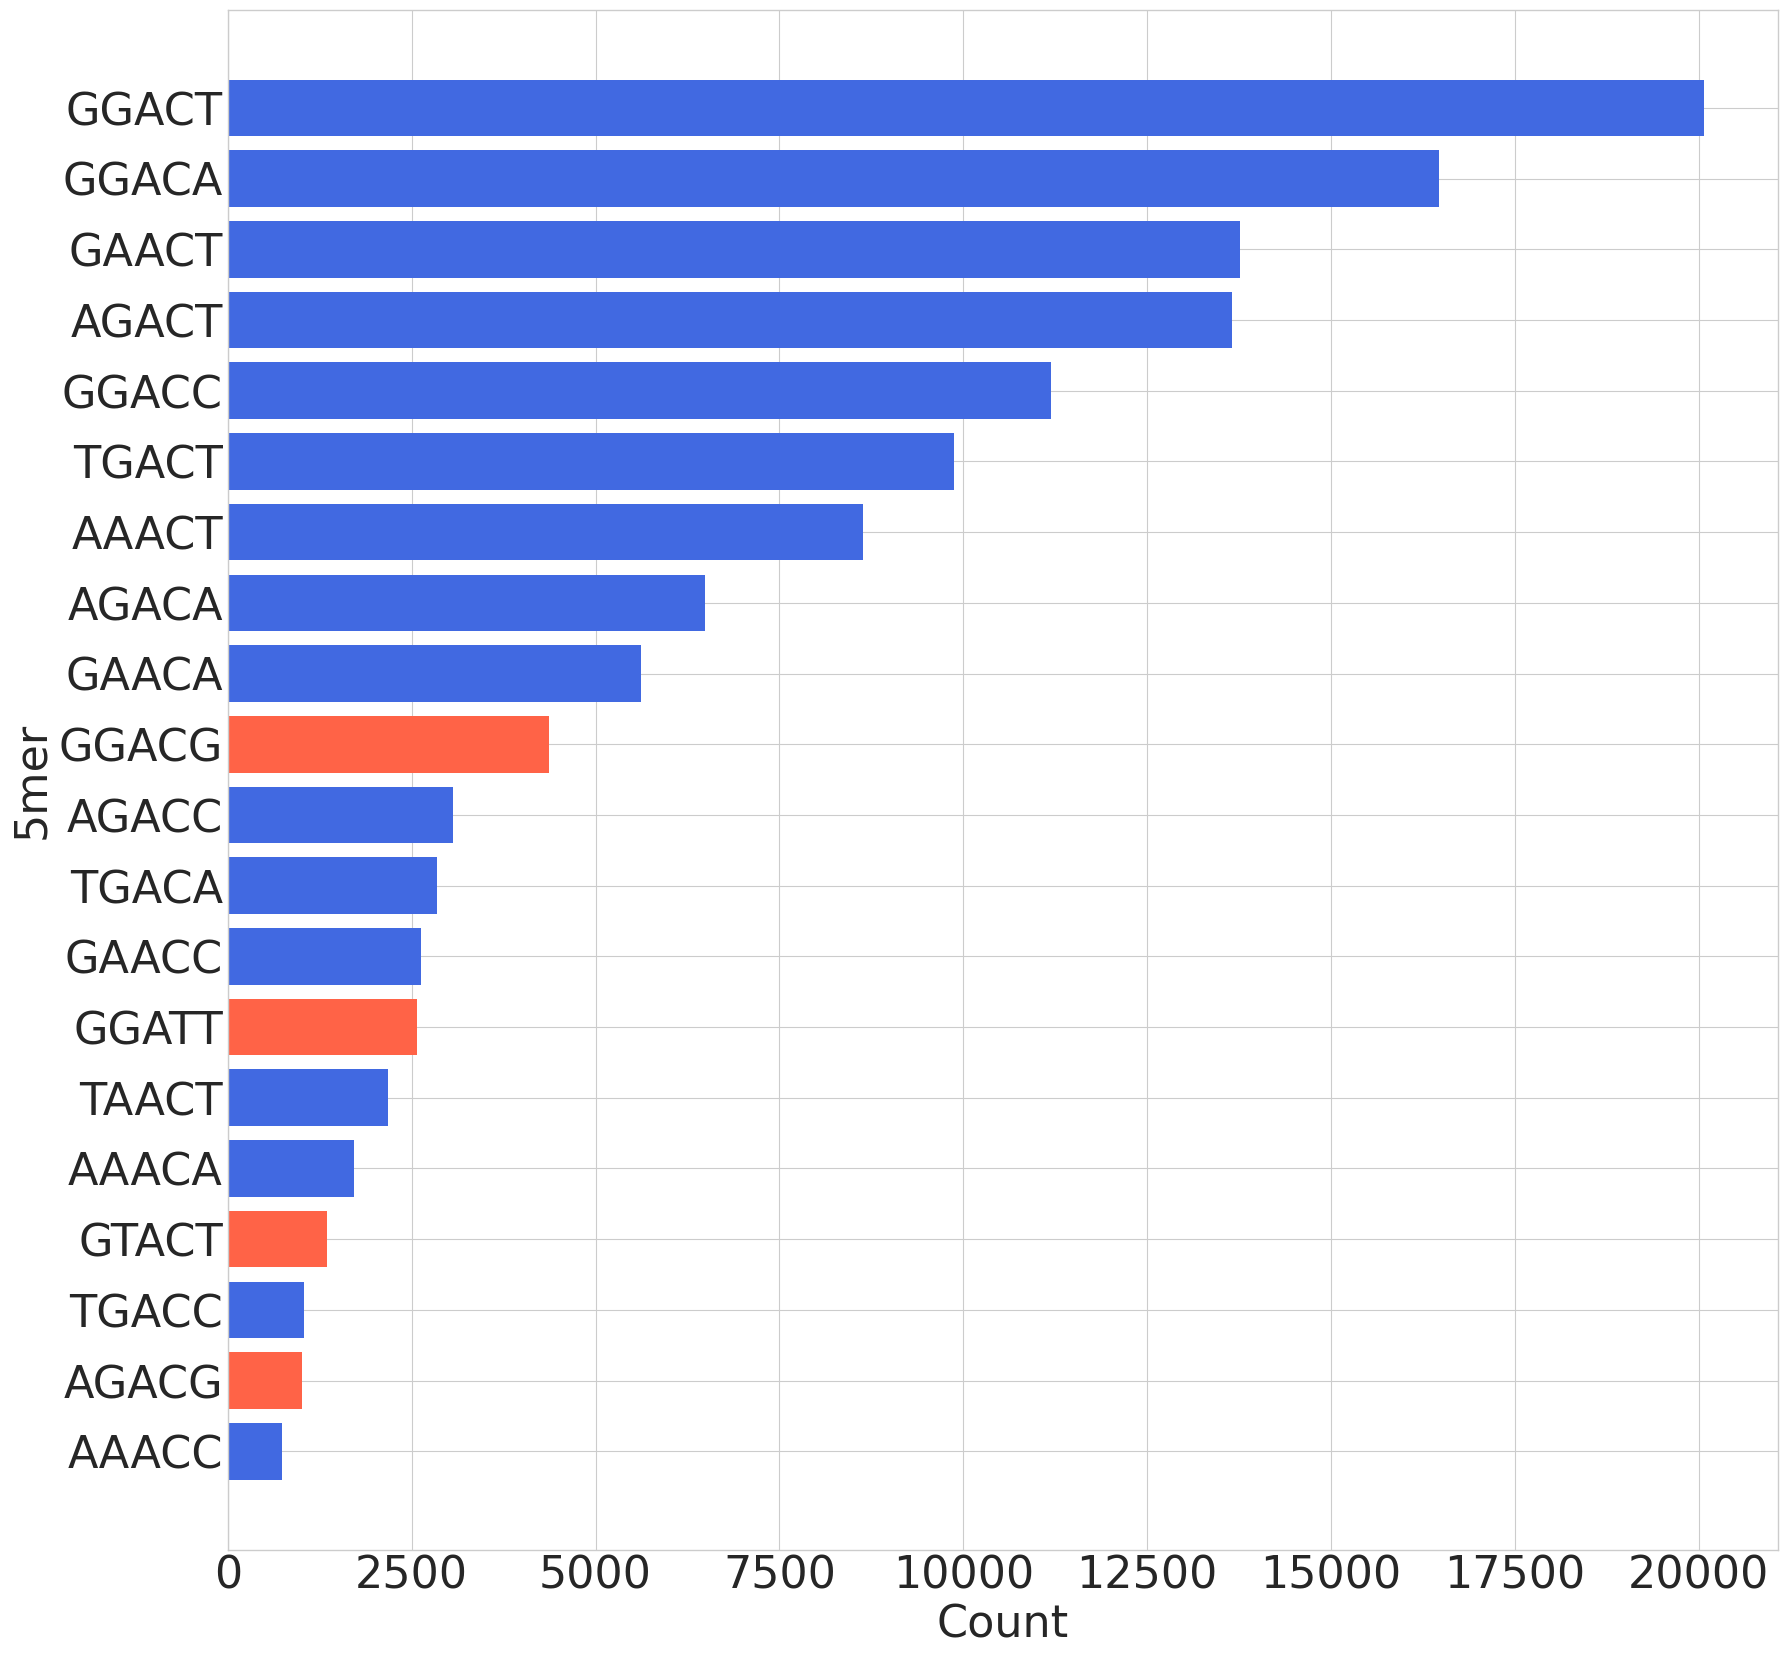

In [37]:
## Plot Top 20 5mers


df = hek_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hek.pdf", format="pdf")
plt.show()

     5mer  count
0   GGACT  17169
1   GGACA  14063
2   GAACT  11788
3   AGACT  11733
4   GGACC   9638
5   TGACT   8620
6   AAACT   7163
7   AGACA   5457
8   GAACA   4715
9   GGACG   3574
10  AGACC   2636
11  TGACA   2462
12  GAACC   2408
13  GGATT   2221
14  TAACT   1839
15  AAACA   1451
16  GTACT   1168
17  TGACC    932
18  AGACG    858
19  CAACT    670


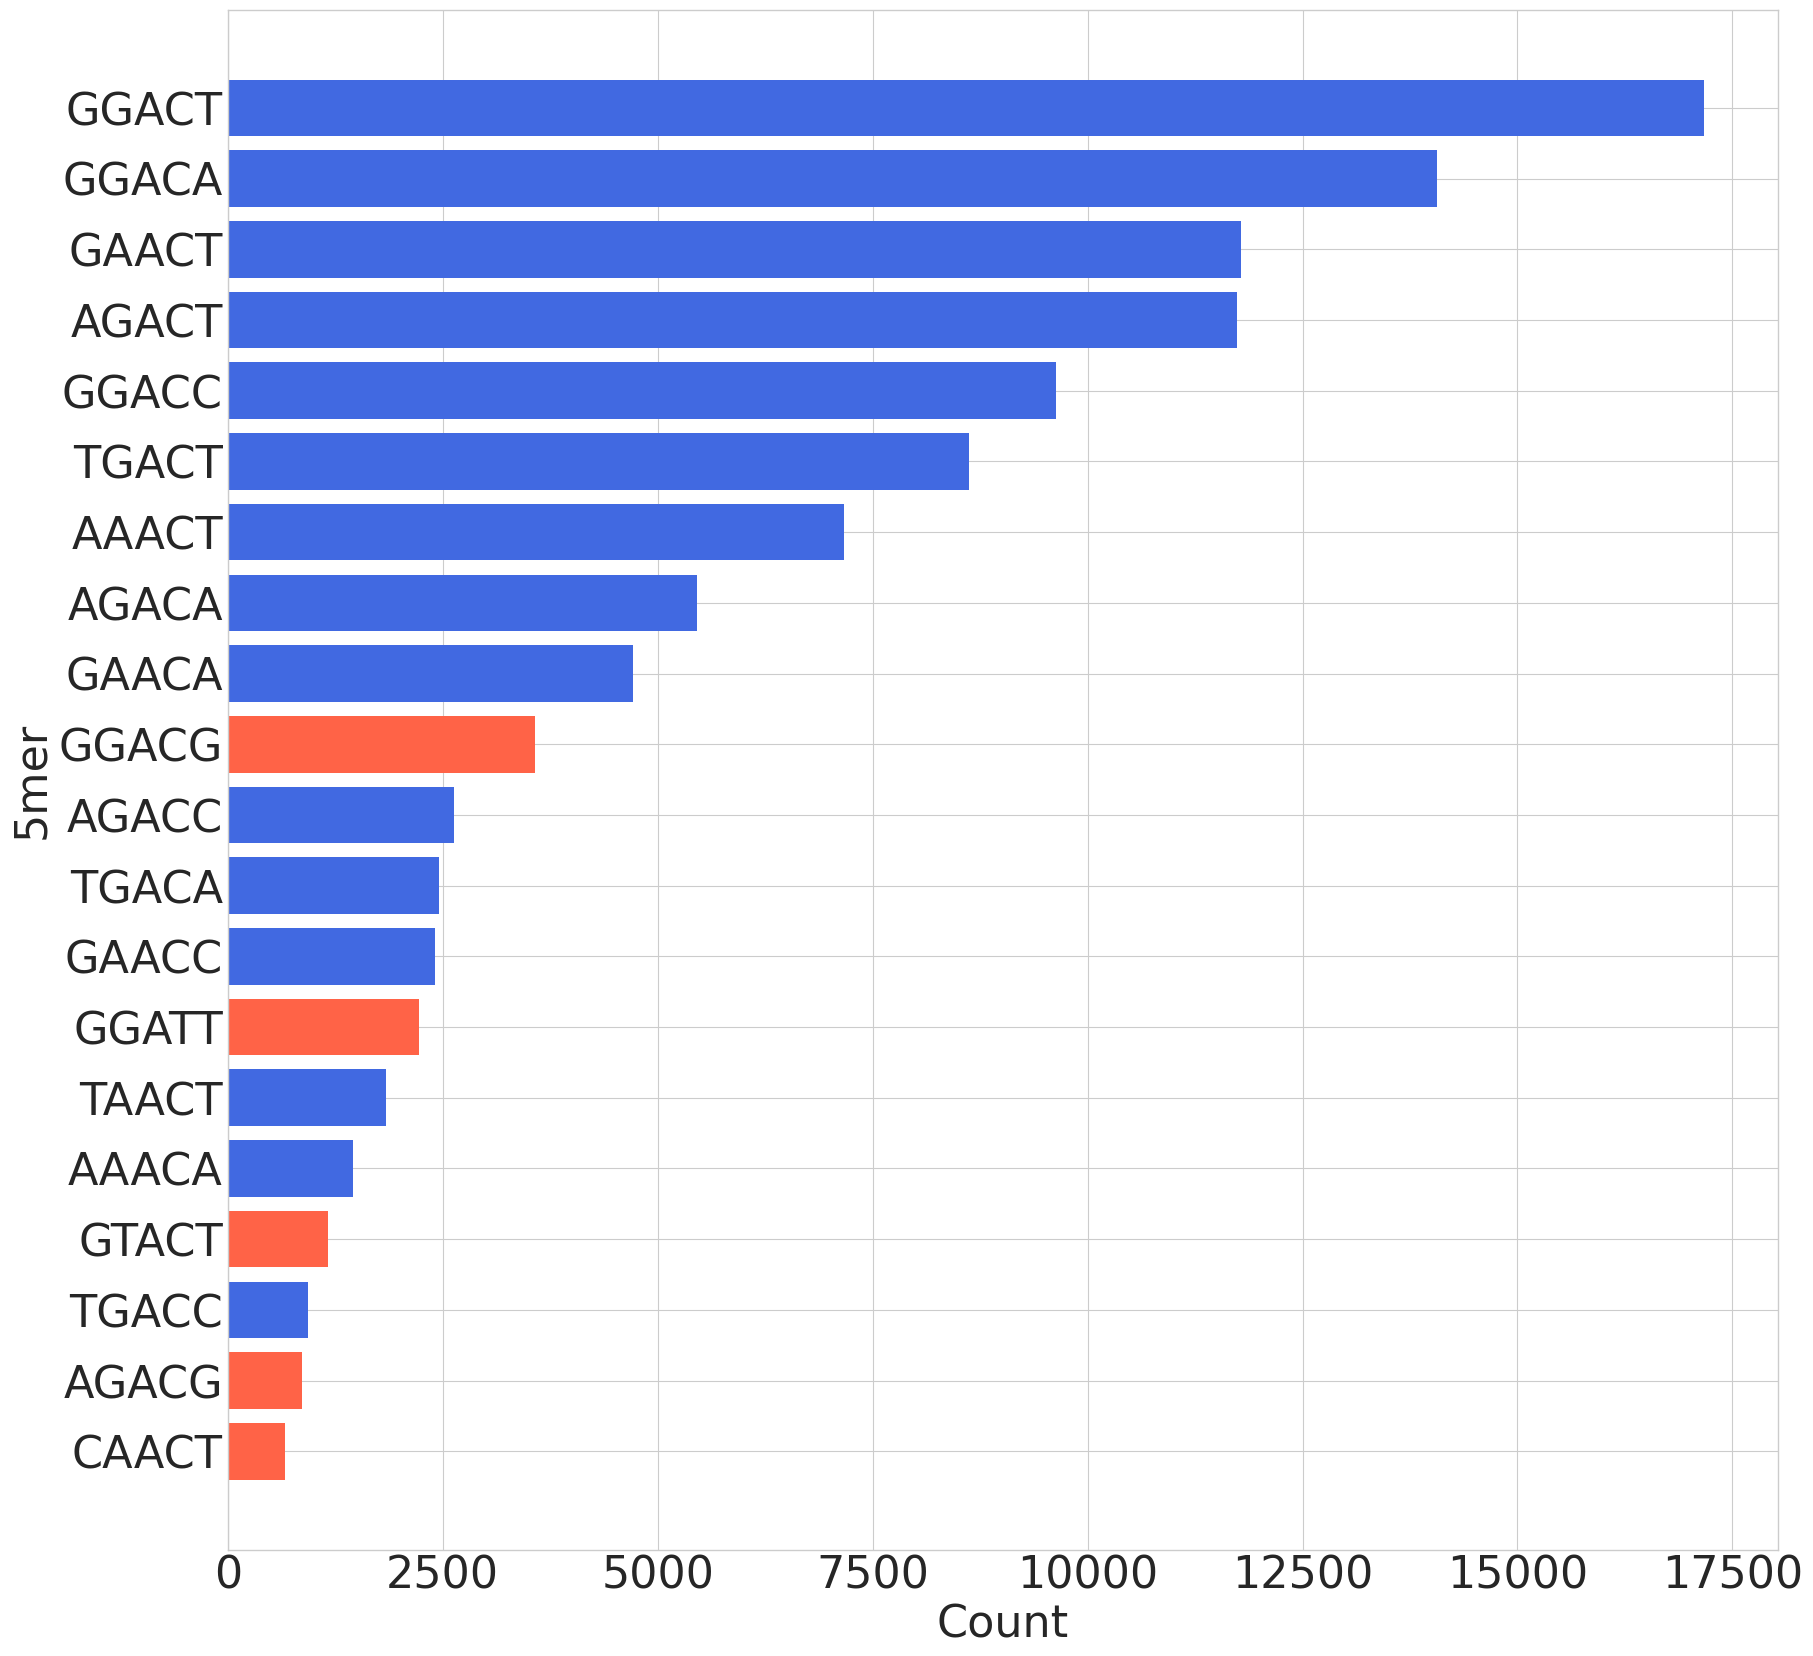

In [38]:
## Plot Top 20 5mers

df = hela_eval_5mer
def is_drach(seq):
    seq = seq.upper()
    if re.search(r'[AGUT][AG]AC[ACUT]', seq):
        return True
    else:
        return False

fig, ax = plt.subplots(1, 1, figsize=(20, 20))
count_5mers = df["5mer"].value_counts().head(20)

## Color by DRACH: True: Royalblue, False: Tomato
## use is_drach function
count_5mers = count_5mers.reset_index()

print(count_5mers)
count_5mers["drach"] = count_5mers["5mer"].apply(is_drach)
count_5mers["color"] = count_5mers["drach"].map({True: "royalblue", False: "tomato"})
count_5mers.sort_values("count", inplace=True)
ax.barh(count_5mers["5mer"], count_5mers["count"], color=count_5mers["color"])
ax.set_xlabel("Count")
ax.set_ylabel("5mer")
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top20_5mers_hela.pdf", format="pdf")
plt.show()

In [39]:
import logomaker as lm
from Bio import SeqIO

In [40]:
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}

In [41]:
hela_m6a_transcript = hek_transcript_label.merge(hela_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")
hek_m6a_transcript = hek_transcript_label.merge(hek_genomic_df_m6a[["genome_id"]].reset_index(drop=True), on="genome_id", how="inner")

In [42]:
hela_m6a_transcript["9mer"] = hela_m6a_transcript.apply(lambda x: fasta_dict[x["nmid"]].seq[x["pos"]-4:x["pos"]+5], axis=1)
hek_m6a_transcript["9mer"] = hek_m6a_transcript.apply(lambda x: fasta_dict[x["nmid"]].seq[x["pos"]-4:x["pos"]+5], axis=1)

In [43]:
hela_m6a_genomic_9mer = hela_m6a_transcript.groupby("genome_id").agg({"9mer": np.unique}).reset_index()
hek_m6a_genomic_9mer = hek_m6a_transcript.groupby("genome_id").agg({"9mer": np.unique}).reset_index()

In [44]:
hela_m6a_genomic_9mer = np.concatenate(hela_m6a_genomic_9mer["9mer"].values)
hek_m6a_genomic_9mer = np.concatenate(hek_m6a_genomic_9mer["9mer"].values)

In [45]:
hela_m6a_genomic_9mer = pd.DataFrame(hela_m6a_genomic_9mer, columns=["9mer"])
hek_m6a_genomic_9mer = pd.DataFrame(hek_m6a_genomic_9mer, columns=["9mer"])

In [46]:
hela_m6a_genomic_9mer["length"] = hela_m6a_genomic_9mer["9mer"].apply(len)
hela_m6a_genomic_9mer = hela_m6a_genomic_9mer[hela_m6a_genomic_9mer["length"] == 9]
hek_m6a_genomic_9mer["length"] = hek_m6a_genomic_9mer["9mer"].apply(len)
hek_m6a_genomic_9mer = hek_m6a_genomic_9mer[hek_m6a_genomic_9mer["length"] == 9]

In [47]:
hela_m6a_genomic_9mer[list(range(9))] = hela_m6a_genomic_9mer.apply(lambda x: list(x["9mer"]), axis=1, result_type="expand")
hek_m6a_genomic_9mer[list(range(9))] = hek_m6a_genomic_9mer.apply(lambda x: list(x["9mer"]), axis=1, result_type="expand")

In [48]:
hela_logo_df = hela_m6a_genomic_9mer[list(range(9))].apply(pd.Series.value_counts).fillna(0).astype(int).T
hek_logo_df = hek_m6a_genomic_9mer[list(range(9))].apply(pd.Series.value_counts).fillna(0).astype(int).T

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


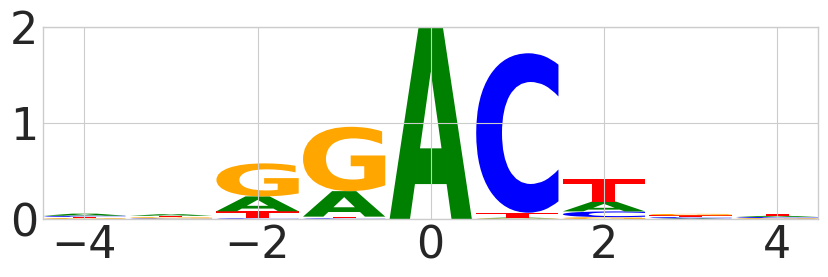

In [49]:
bit_df = hela_logo_df.copy()
bit_df.index = np.arange(9) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hela.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/pandas/core/arraylike.py:396: RuntimeWarning: divide by zero encountered in log2
  result = getattr(ufunc, method)(*inputs, **kwargs)


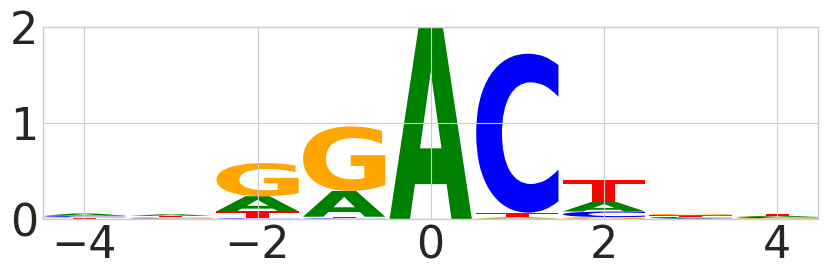

In [50]:
bit_df = hek_logo_df.copy()
bit_df.index = np.arange(9) - 4
bit_df = bit_df.apply(lambda x: x/x.sum(), axis=1)
bit_df = bit_df.apply(lambda x: x*(2+(x*np.log2(x)).sum()), axis=1)
logo = lm.Logo(bit_df.fillna(0), color_scheme="classic")
plt.xticks([-4,-2,0,2,4])
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/seqlogo_hek.pdf", format="pdf")
plt.show()


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


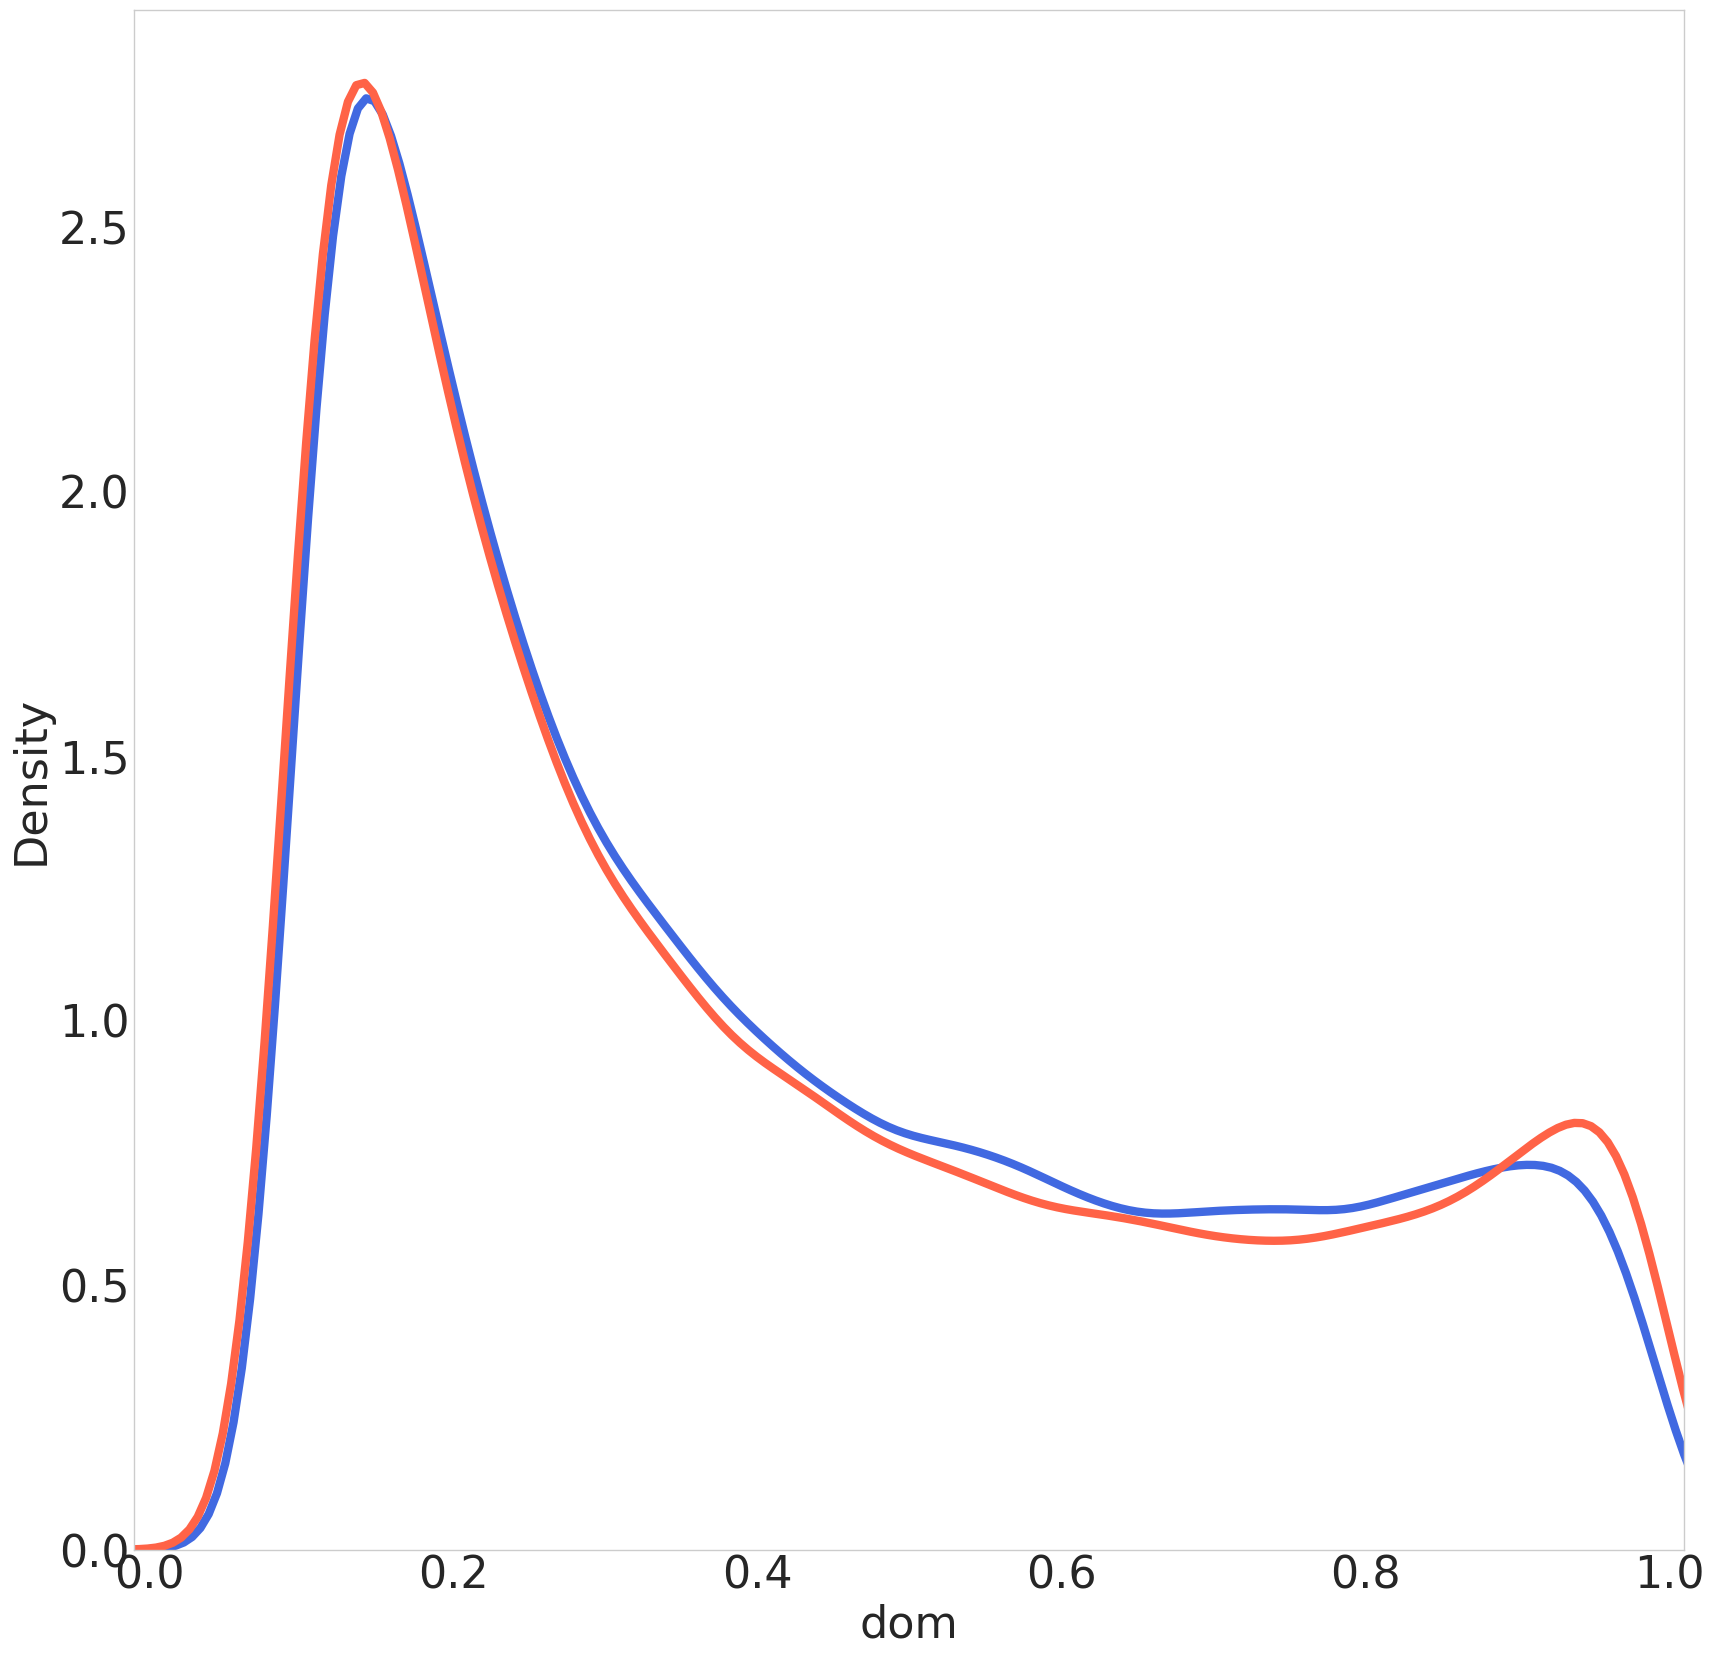

In [51]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval, x="dom", ax=ax, fill=False, levels=100, color="royalblue", alpha=1.0)
sns.kdeplot(data=hela_eval, x="dom", ax=ax, fill=False, levels=100, color="tomato",  alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_distribution.pdf", format="pdf")
plt.show()

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


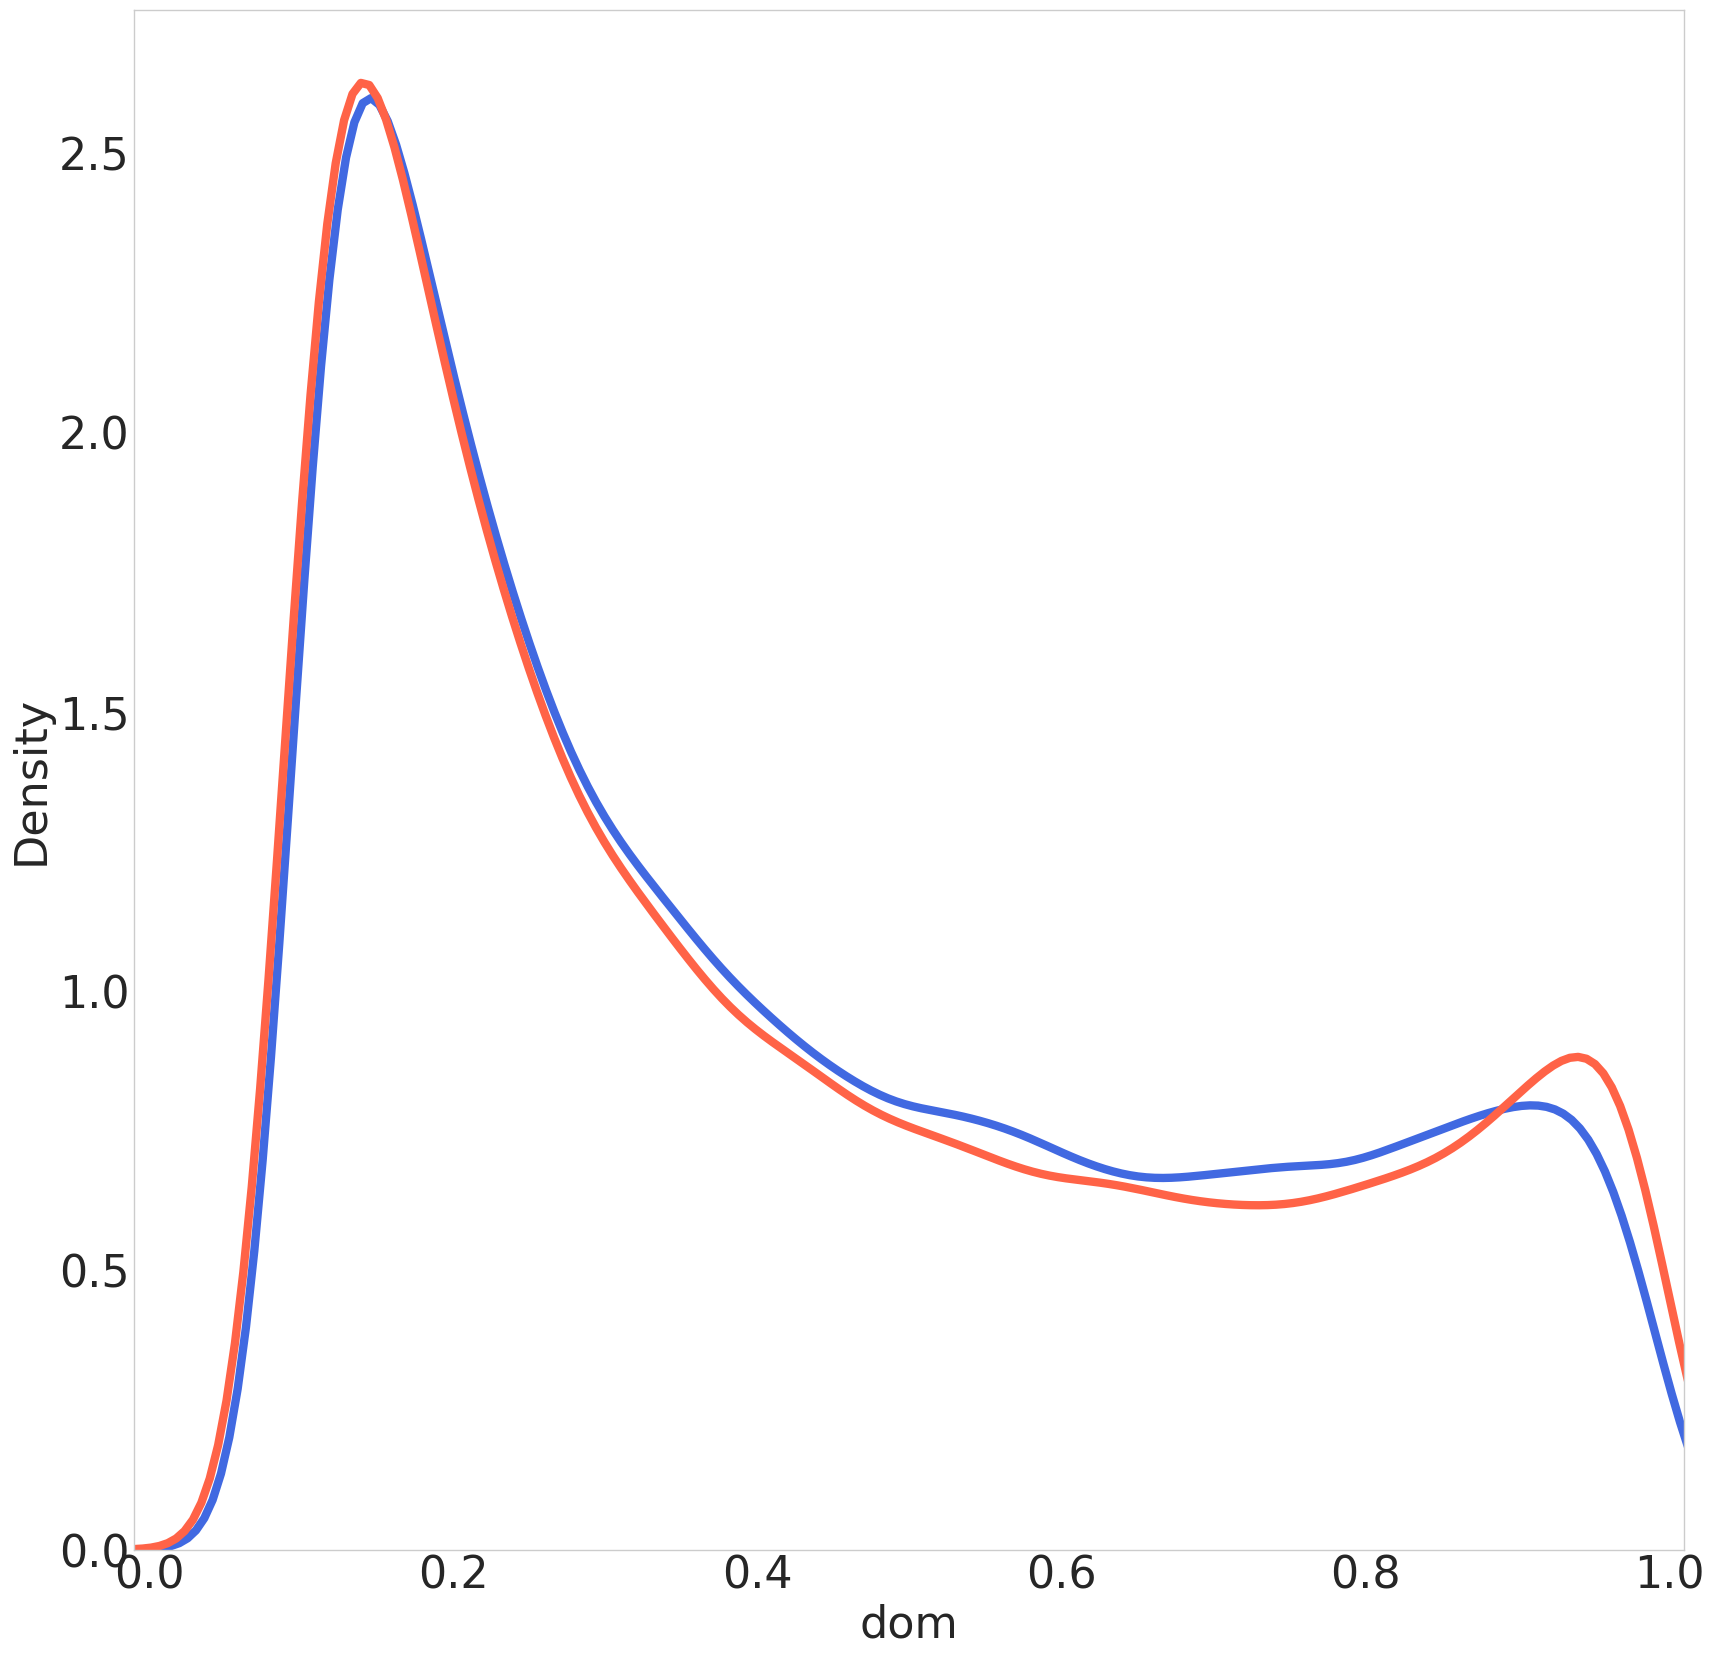

In [52]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_drach.pdf", format="pdf")
plt.show()

In [59]:
hek_eval["drach"] = hek_eval["drach"].astype(bool)
hela_eval["drach"] = hela_eval["drach"].astype(bool)

/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


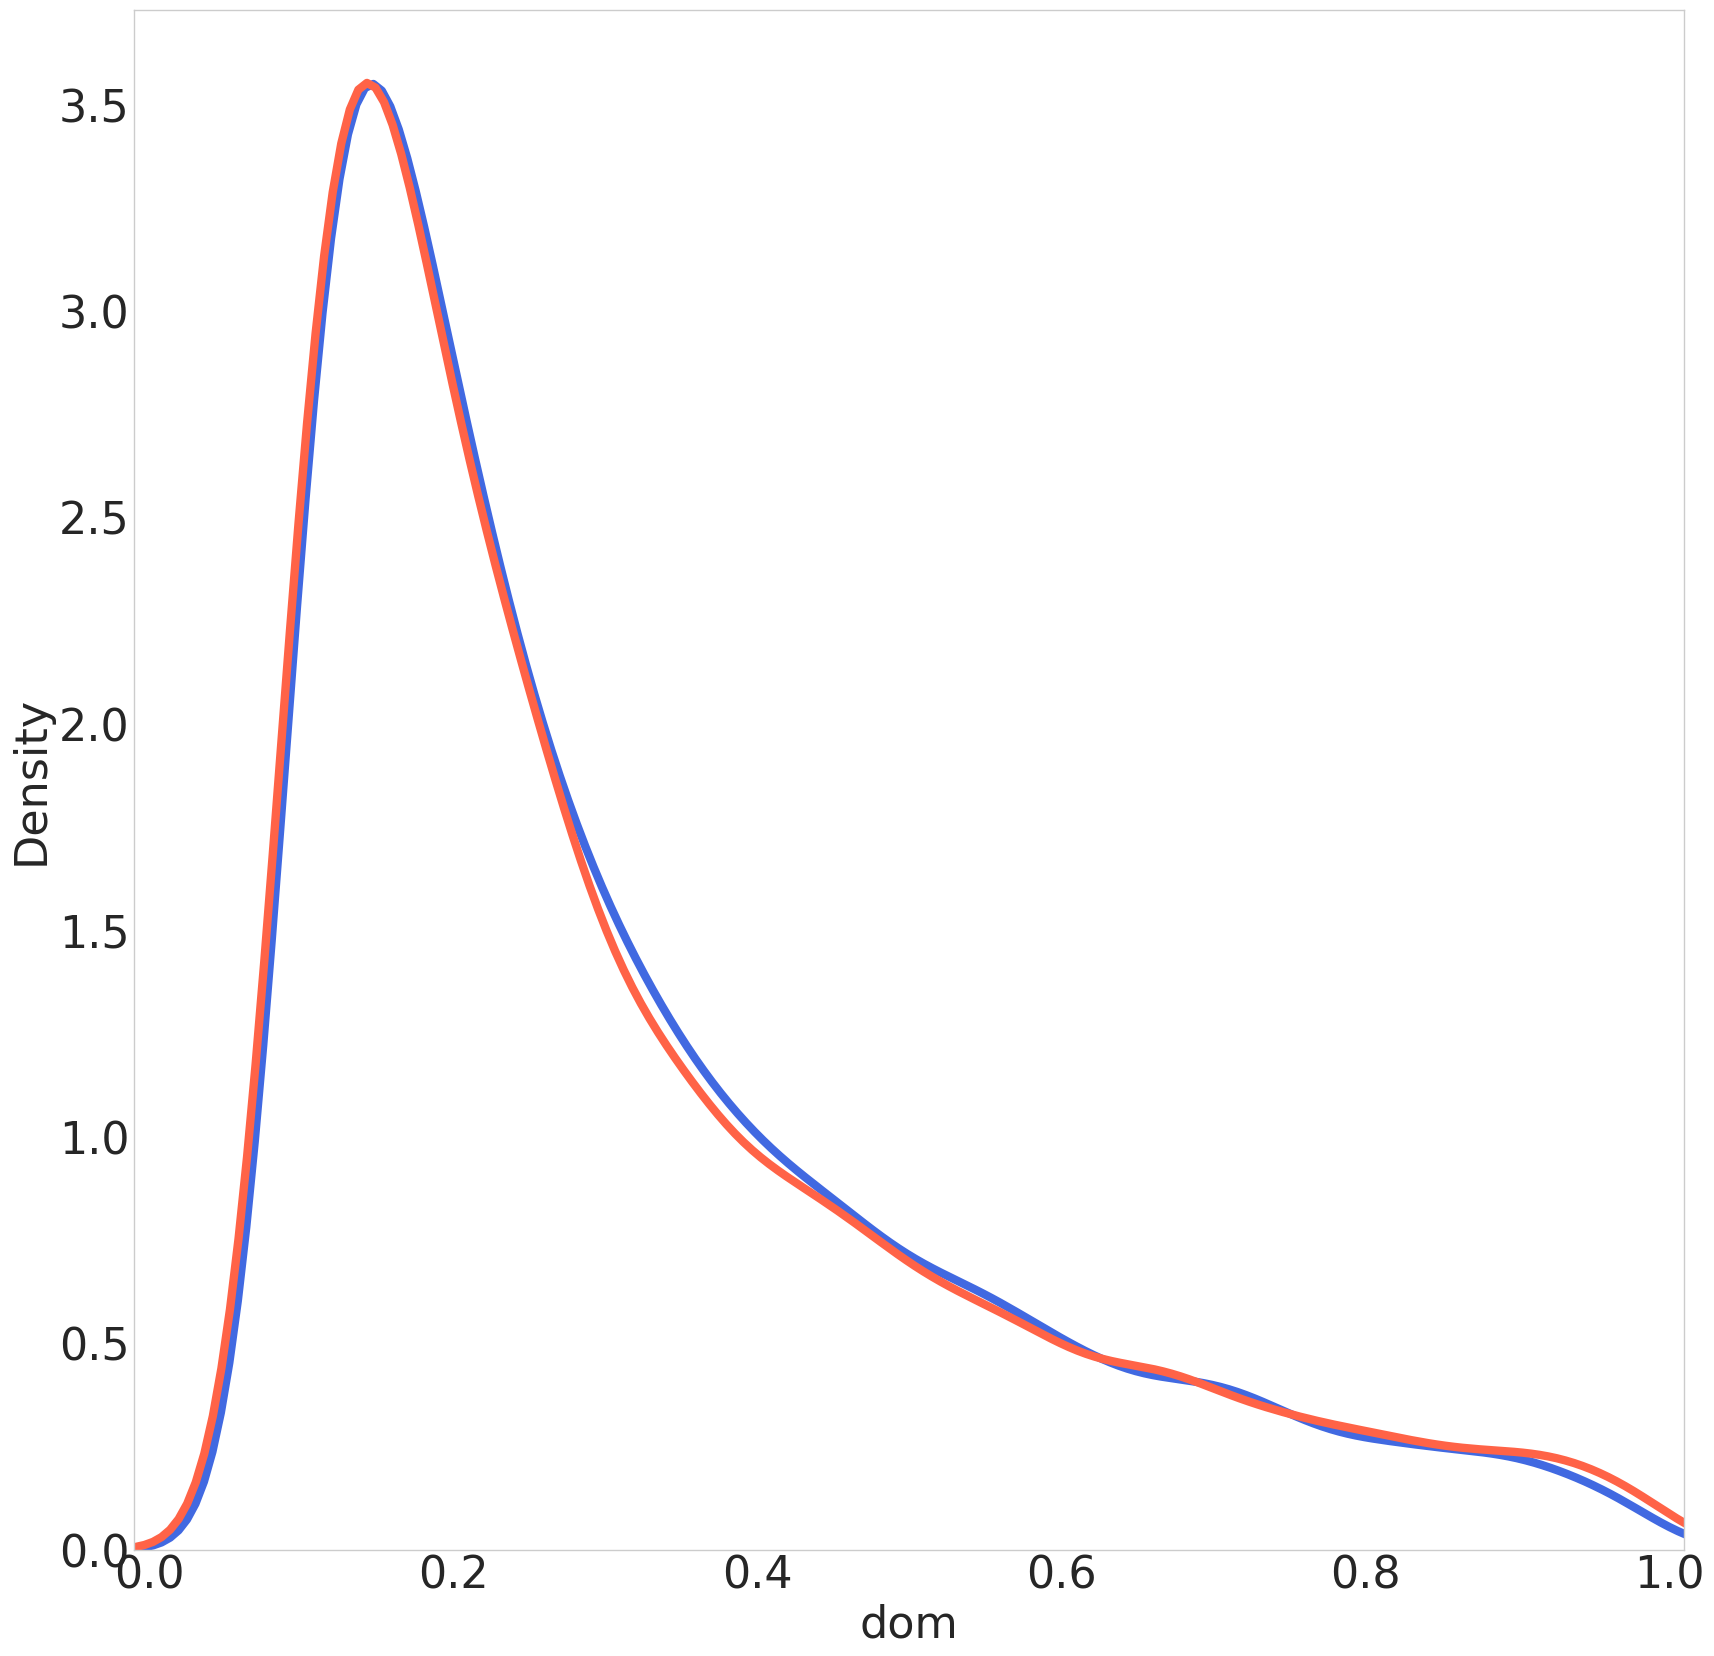

In [60]:
## DOM DISTRIBUTION kde

fig, ax = plt.subplots(1, 1, figsize=(20, 20))

sns.kdeplot(data=hek_eval[~hek_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="royalblue",  alpha=1.0)
sns.kdeplot(data=hela_eval[~hela_eval["drach"]], x="dom", ax=ax, fill=False, levels=100, color="tomato",   alpha=1.0)

ax.set_xlim(-0.01, 1.01)
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/dom_nondrach.pdf", format="pdf")
plt.show()

In [61]:
hela_m6a_count = hela_genomic_df_m6a.groupby("gene_symbol").size()
hek_m6a_count = hek_genomic_df_m6a.groupby("gene_symbol").size() 

print(hela_m6a_count)
print(hek_m6a_count)

gene_symbol
A4GALT    20
AACS       5
AADAT      7
AAGAB      3
AAK1       8
          ..
ZYG11A    12
ZYG11B     2
ZYX        1
ZZEF1     30
ZZZ3      30
Length: 10278, dtype: int64
gene_symbol
A1BG         1
A1BG-AS1    17
A4GALT      22
AACS         5
AADAT        9
            ..
ZYG11A      14
ZYG11B       6
ZYX          1
ZZEF1       31
ZZZ3        29
Length: 11421, dtype: int64


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


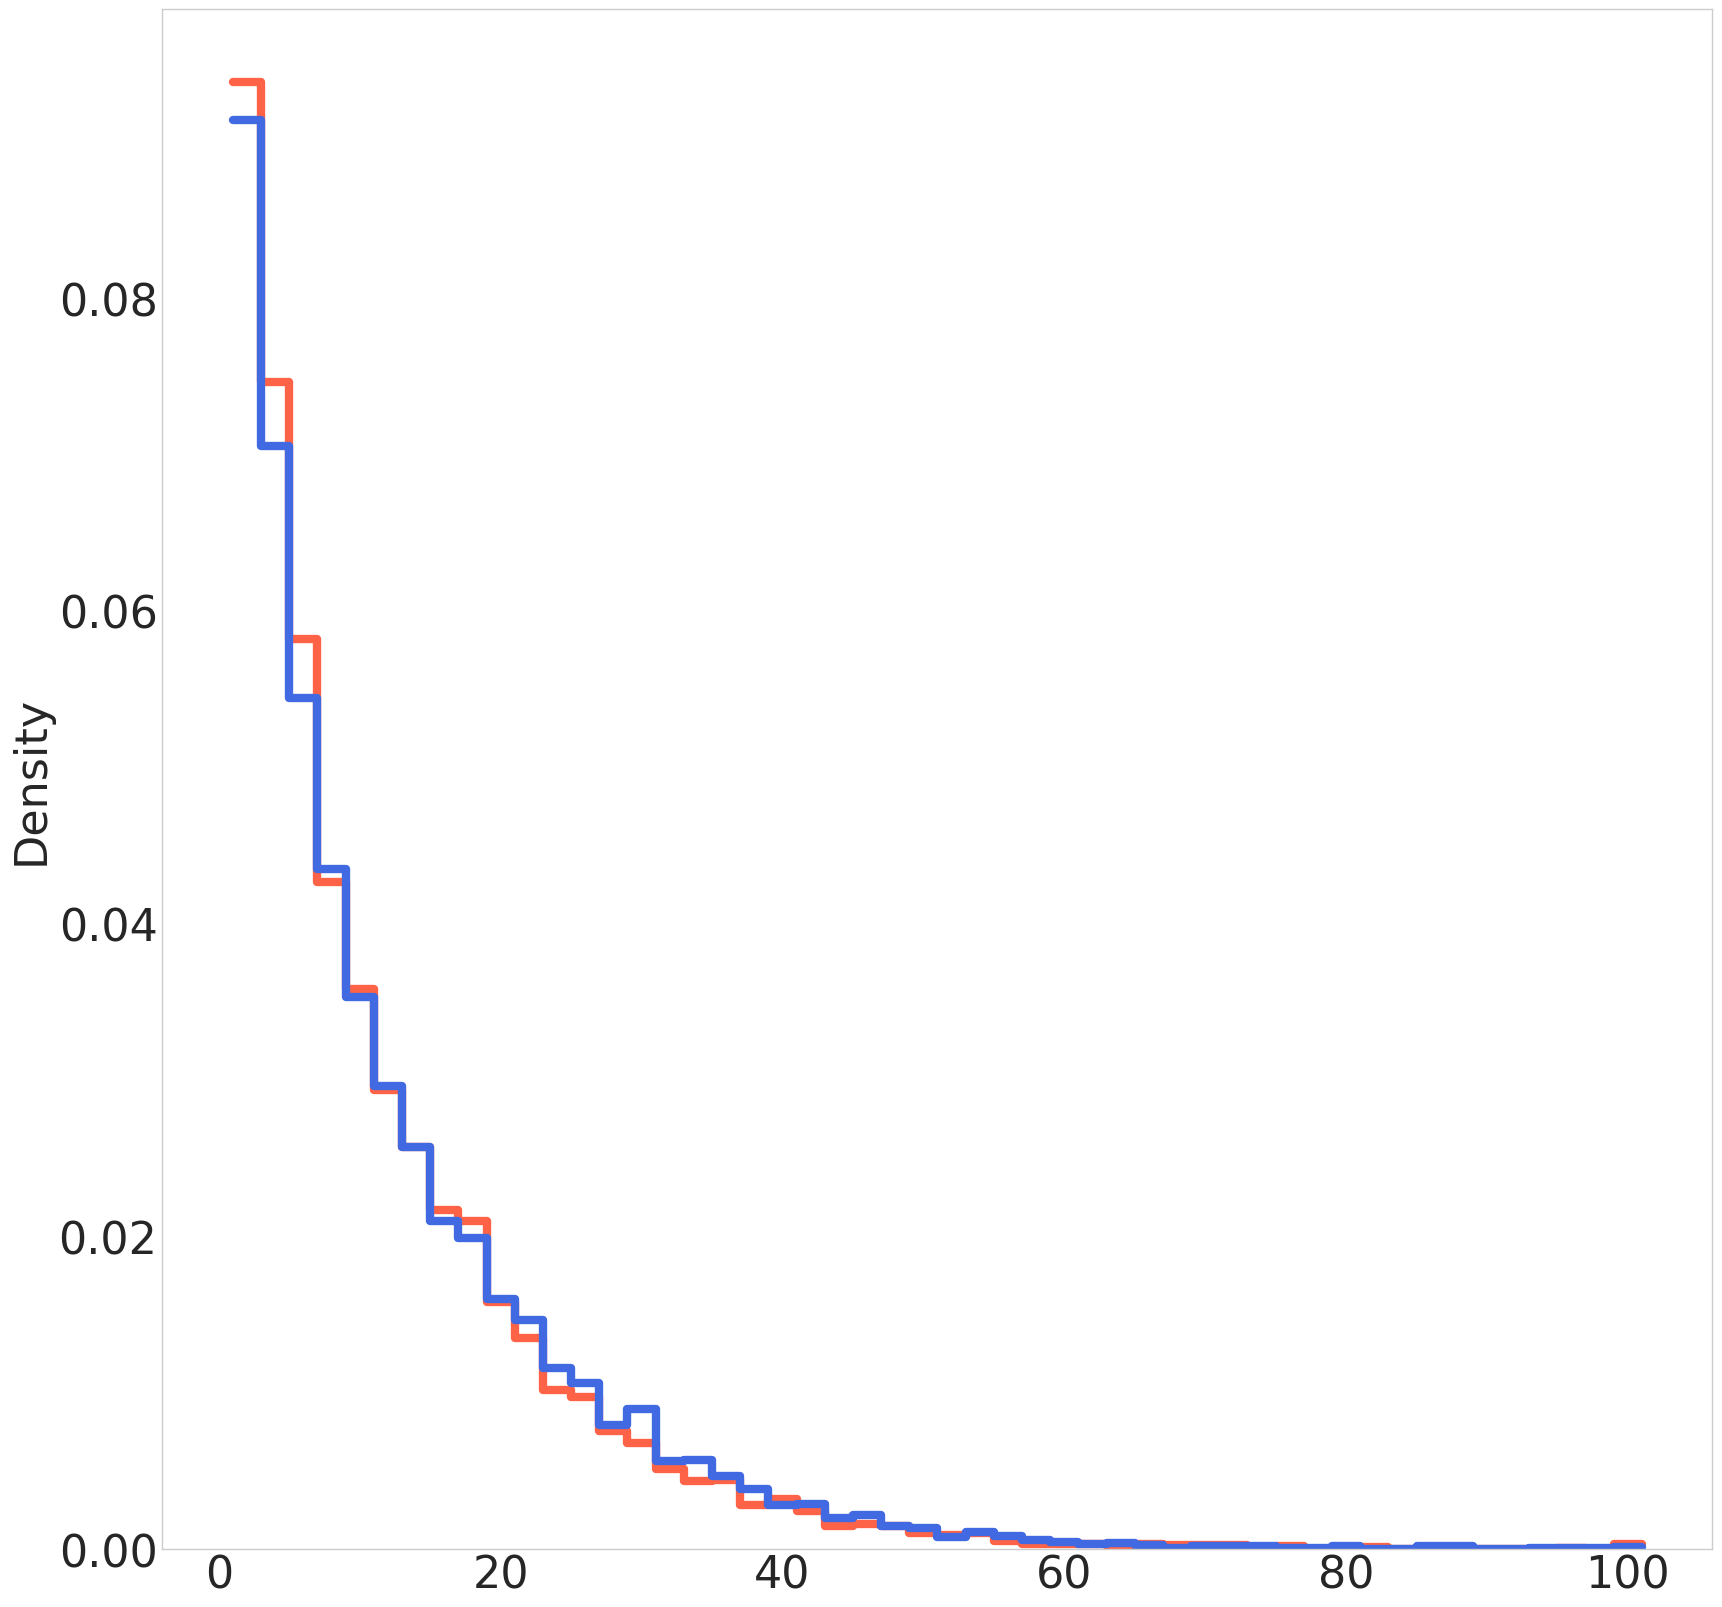

In [62]:
## Plot histogram
fig, ax = plt.subplots(figsize=(20,20))
sns.histplot(np.clip(hela_m6a_count, 0, 100), color="tomato", label="HeLa", element="step", ax=ax, fill=False, binwidth=2, stat="density")
sns.histplot(np.clip(hek_m6a_count,  0, 100), color="royalblue", label="HEK293T", element="step", ax=ax, fill=False, binwidth=2, stat="density")
ax.grid(False)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/density.pdf", format="pdf")
plt.show()

In [63]:
## How many genes have> 30 m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 20])/len(hela_m6a_count))
print(len(hek_m6a_count[hek_m6a_count  > 20])/len(hek_m6a_count))

0.1628721541155867
0.18518518518518517


In [64]:
## How many genes have m6A sites?
print(len(hela_m6a_count[hela_m6a_count > 0])/hela_genomic_df["gene_symbol"].nunique())
print(len(hek_m6a_count[hek_m6a_count > 0])/hek_genomic_df["gene_symbol"].nunique())

0.8647875473285654
0.8618321762752792


In [65]:
## Average number of m6A sites per gene
print(hela_m6a_count.mean())
print(hek_m6a_count.mean())

11.355711227865344
11.953856930216268


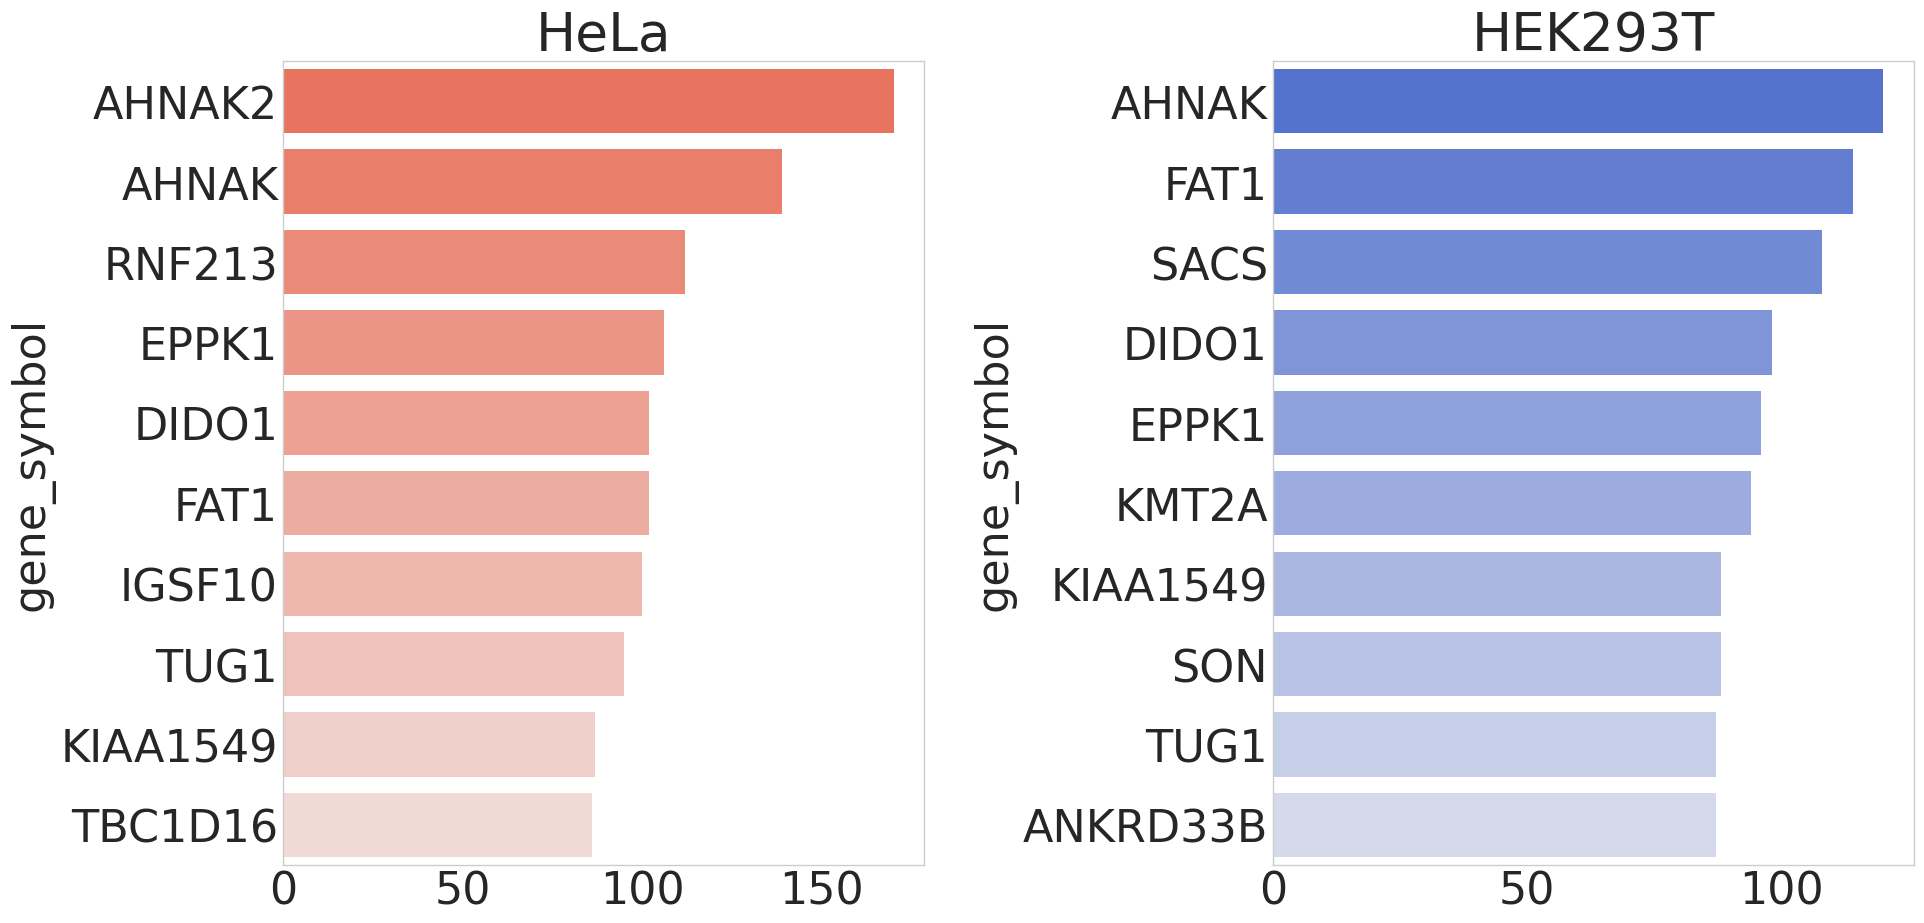

In [66]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
hela_arr = hela_m6a_count.sort_values(ascending=False)
hek_arr = hek_m6a_count.sort_values(ascending=False)
## Vertical bar plot
sns.barplot(x=hela_arr[:10], y=hela_arr[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_arr[:10], y=hek_arr[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [67]:
##print top10 genes

print("\n".join(hela_arr[:100].index))
print("")
print("\n".join(hek_arr[:100].index))

AHNAK2
AHNAK
RNF213
EPPK1
DIDO1
FAT1
IGSF10
TUG1
KIAA1549
TBC1D16
SON
INF2
ZNF469
PLEC
MKI67
SLITRK5
ZCCHC14
ARHGAP35
ZBTB38
CELSR1
SMCR8
MPRIP
ZNF646
ERC1
IRS1
MYORG
DAG1
PRECSIT
KCNQ1OT1
ANKRD11
FAT4
ZNF318
MGA
IGF1R
KIF1B
ING5
MYOCD
AHDC1
TANC2
ASXL1
OPN3
SPEN
SLITRK4
NRIP1
KLHL5
TASOR2
RANBP6
SYNM
ZBED4
ARHGAP21
NSD1
CHST3
PHF3
CELSR3
SRCAP
CENPF
PDCD6-AHRR
DISP1
CELSR2
MICAL3
PKD1
GLI2
ADNP2
ZNF12
SAMD9
SACS
TMEM184A
FOXK2
WDR81
RAI1
TSHZ1
PCDH7
ITPRIP
VCPIP1
TADA2B
TSHZ2
ADCY9
CDK13
PRAG1
SEC16A
BCL9L
SETD2
CLEC16A
ZNF142
TCF20
RBM12B
NSD2
BPTF
C15orf39
ALG11
MUC16
TNS3
URGCP
ZBED1
CAMSAP1
MN1
SNX29
SETD1B
TNRC6A
MSL2

AHNAK
FAT1
SACS
DIDO1
EPPK1
KMT2A
KIAA1549
SON
TUG1
ANKRD33B
MKI67
SPEN
TBC1D16
FAT4
SMCR8
PEAK1
H6PD
ING5
ARHGAP35
ALMS1
PLXNA2
ERC1
ANKRD11
PCDH7
CELSR2
CELSR1
VCAN
ZNF646
SETX
MACF1
LINC00205
LMTK2
MYORG
RESF1
TASOR2
ZBED4
IGF1R
RANBP6
ZCCHC14
BPTF
ZNF318
ZNF778
PTCHD1
SFMBT2
PLEC
KIF1B
PHF3
IRS1
NSD1
NRIP1
MGA
CHST3
ZNF292
ZKSCAN2
ZNF608
PCDH9
SYNM
SRCAP
ZNF618

In [68]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}
a_count_dict = {x: y.seq.count("A") for x, y in fasta_dict.items()}
## Draw Discrepancy
geneid_table = pd.read_pickle("/extdata4/baeklab/Hyeonseo/m6A/res/ref/GRCh38_latest_genomic.convert_table.pkl")
convert_dict = dict(zip(geneid_table["transcript_id"], geneid_table["gene_id"]))
a_count_df = pd.DataFrame(a_count_dict.items(), columns=["refseq", "a_count"])
a_count_df["gene_id"] = a_count_df["refseq"].map(convert_dict)
a_count_df = a_count_df.groupby("gene_id").agg({"a_count": "mean"})


In [69]:
hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]
hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]
hela_count_df = pd.DataFrame(hela_m6a_df["refseq"].value_counts())
hek_count_df = pd.DataFrame(hek_m6a_df["refseq"].value_counts())

hela_count_df["a_count"] = hela_count_df.index.map(a_count_dict)
hek_count_df["a_count"] = hek_count_df.index.map(a_count_dict)

hela_count_df["density"] = hela_count_df["count"]/hela_count_df["a_count"]
hek_count_df["density"] = hek_count_df["count"]/hek_count_df["a_count"]

hela_count_df["gene_id"] = hela_count_df.index.map(convert_dict)
hek_count_df["gene_id"] = hek_count_df.index.map(convert_dict)

print(hela_count_df)
print(hek_count_df)

/tmp/ipykernel_62109/1680434609.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
/tmp/ipykernel_62109/1680434609.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]


              count  a_count   density  gene_id
refseq                                         
NM_138420       147     4423  0.033235   AHNAK2
NM_001350929    138     4406  0.031321   AHNAK2
NM_001620       126     5444  0.023145    AHNAK
NM_001346446    124     5446  0.022769    AHNAK
NM_031308       106     2710  0.039114    EPPK1
...             ...      ...       ...      ...
NM_152551         1     1270  0.000787  SNRNP48
NM_001284212      1     1432  0.000698     CAST
NM_031266         1      434  0.002304  HNRNPAB
NM_016047         1      211  0.004739    SF3B6
NM_004860         1      648  0.001543     FXR2

[19567 rows x 4 columns]
              count  a_count   density   gene_id
refseq                                          
NM_005245       114     4184  0.027247      FAT1
NM_031308        96     2710  0.035424     EPPK1
NM_001291411     92     2136  0.043071       SON
NM_001620        91     5444  0.016716     AHNAK
NM_001398477     90     2044  0.044031      TUG1
...    

In [70]:
## groupby gene_id, get max density, sort by density
hela_density_df = hela_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)
hek_density_df = hek_count_df.groupby("gene_id").agg({"density": "max"}).sort_values("density", ascending=False)

print(hela_density_df)
print(hek_density_df)

          density
gene_id          
RNU6-2   0.125000
EXD3     0.114198
ADAT3    0.113861
MFSD5    0.100000
MC1R     0.090674
...           ...
ASXL2    0.000264
HELZ     0.000245
SUGT1    0.000244
SLFN12L  0.000235
HOOK3    0.000230

[9918 rows x 1 columns]
           density
gene_id           
EXD3      0.126543
ADAT3     0.108911
MFSD5     0.100000
MC1R      0.093264
SDHAF1    0.088235
...            ...
ZNF483    0.000247
HOOK3     0.000230
ZNF431    0.000228
DYNC2H1   0.000226
NOPCHAP1  0.000171

[11042 rows x 1 columns]


In [71]:
print(", ".join(hek_density_df.index[:100]))

EXD3, ADAT3, MFSD5, MC1R, SDHAF1, RPRML, PWWP2B, HPS6, C19orf73, OXLD1, UFSP1, LRFN4, FJX1, B3GALT6, CITED4, SCO2, HDHD3, TMEM121, KCNJ4, LARRPM, FAM110A, UQCC4, TIMM29, SSR4P1, TMEM177, NCBP2AS2, CHST14, ASH1L-AS1, KTI12, OXCT2, GP1BB, TMEM115, TMEM276, IMP3, CPTP, FNDC10, MRPS12, C15orf39, TMEM203, LRFN1, DEXI, LOC642361, DOLK, SLC25A29, ABHD15, UBALD1, LOC101928120, RIOX1, RAB40C, TUSC1, FRAT1, URGCP, LINGO1, MPDU1-AS1, RNF26, LRRN2, KCTD11, KCNG1, ZNF865, CEBPA-DT, BLOC1S4, H2AX, C11orf68, PLEKHF1, ZNF324B, ZBTB45, ZNF581, RNU6-8, RNU6-7, WDR6, UCN, TICAM1, SLC66A2, SLC16A13, GFOD2, ADORA2B, CANT1, FKRP, LOC100129534, FKBPL, CYBC1, FAAP20, C7orf50, ZNF566-AS1, C6orf226, FZD9, FBXO46, CCDC85B, RTN4R, EMILIN3, LPAR2, FOXO6, ARFGAP1, ZBED1, FRAT2, FOXD2-AS1, TXNDC12, PRRT4, PAQR4, MILIP


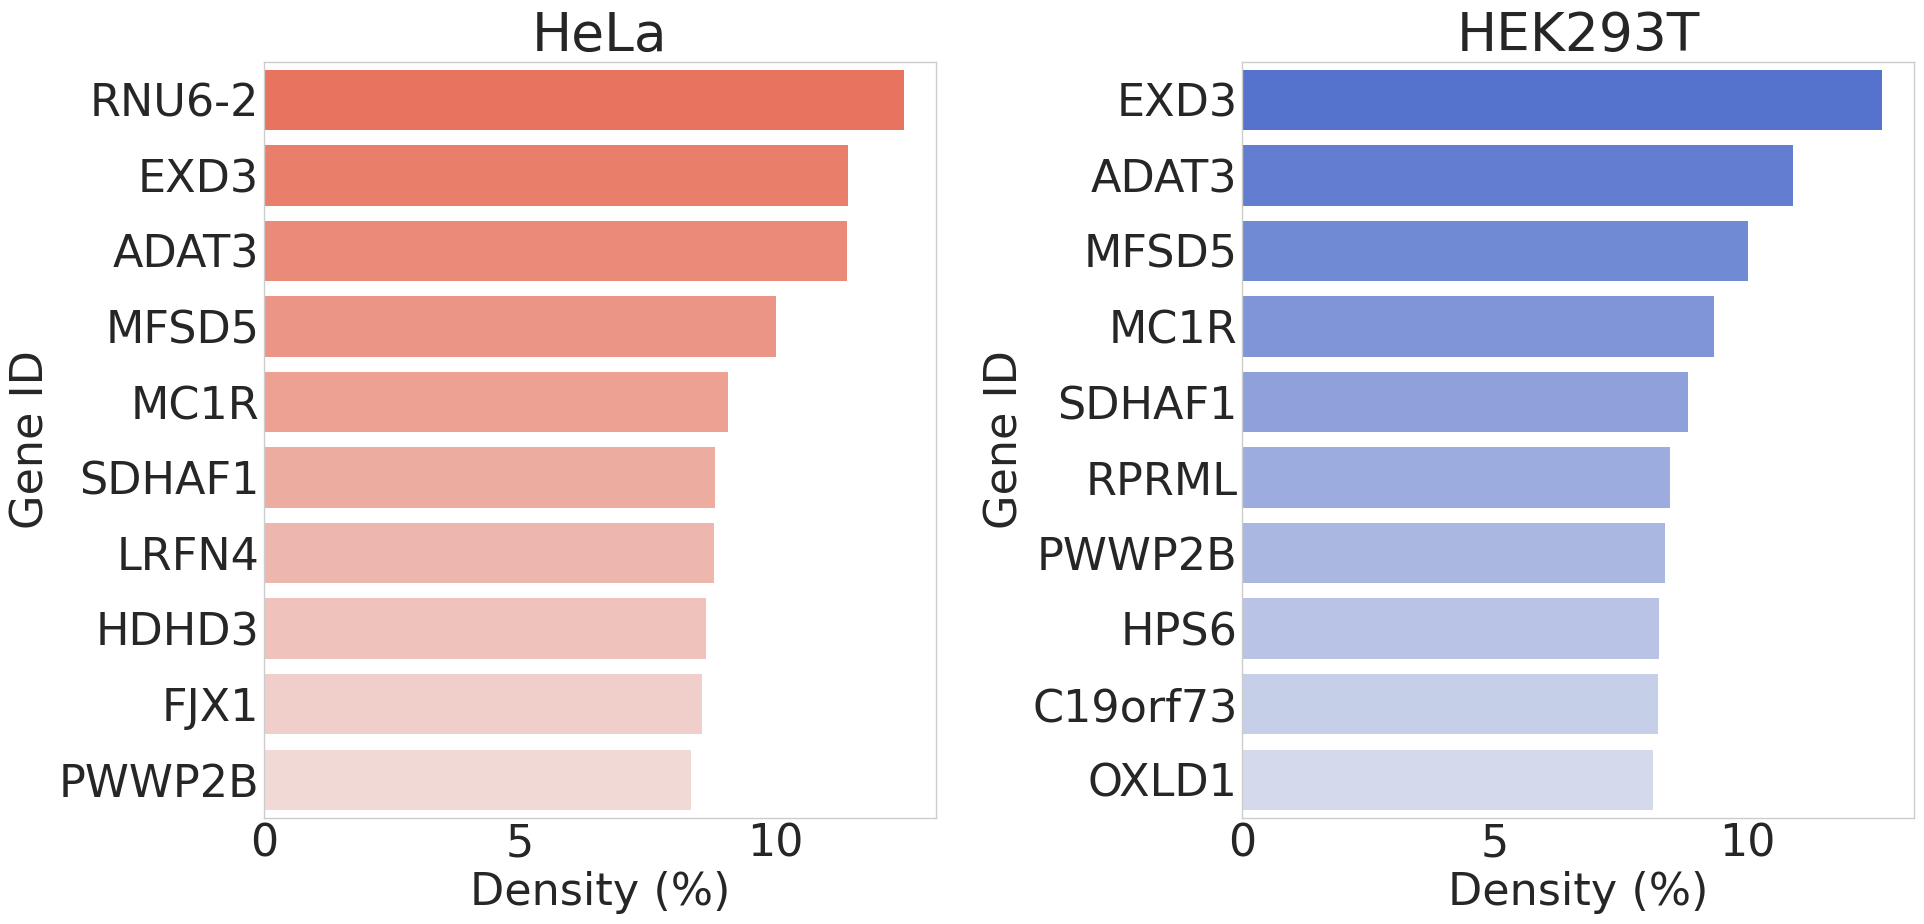

In [72]:
## Plot 10 most heavily m6A modified genes
fig, ax = plt.subplots(1, 2, figsize=(20,10))
## Vertical bar plot
sns.barplot(x=hela_density_df[:10]["density"]*100, y=hela_density_df[:10].index, palette = sns.light_palette("tomato", 12, reverse=True,), ax=ax[0])
sns.barplot(x=hek_density_df[:10]["density"]*100, y=hek_density_df[:10].index, palette = sns.light_palette("royalblue", 12, reverse=True,), ax=ax[1])
ax[0].set_title("HeLa")
ax[1].set_title("HEK293T")
ax[0].grid(False)
ax[1].grid(False)
ax[0].set_xlabel("Density (%)")
ax[1].set_xlabel("Density (%)")
ax[0].set_ylabel("Gene ID")
ax[1].set_ylabel("Gene ID")
plt.tight_layout()
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/top10.pdf", format="pdf")
plt.show()

In [74]:
hek_df["refseq"] = hek_df["label_id"].str.split(":").str[0]
hela_df["refseq"] = hela_df["label_id"].str.split(":").str[0]

In [76]:
hek_df["pos"] = hek_df["label_id"].str.split(":").str[1].astype(np.int32)
hela_df["pos"] = hela_df["label_id"].str.split(":").str[1].astype(np.int32)

In [77]:
hek_count_df = hek_df["refseq"].value_counts()
hela_count_df = hela_df["refseq"].value_counts()
hek_start_df = hek_df.groupby("refseq").apply(lambda x: x["pos"].min())
hela_start_df = hela_df.groupby("refseq").apply(lambda x: x["pos"].min())


In [78]:
from Bio import SeqIO
ref_path = "/extdata4/baeklab/Hyeonseo/m6A/res/ref/isoform/hg38_rna_nrnm.fasta"
fasta_dict = SeqIO.to_dict(SeqIO.parse(ref_path, "fasta"))
fasta_dict = {x.split(".")[0]: y for x, y in fasta_dict.items()}


In [79]:
def get_utr_orf_len(exonstarts, exonends, cdsstart, cdsend, strand):

    if exonstarts[0] == cdsstart:
        utr5_len = 0
    else:
        utr5_end_idx = np.argmax(np.array(exonends) > cdsstart)
        utr5_exonstarts = exonstarts[:utr5_end_idx+1].copy()
        utr5_exonends = exonends[:utr5_end_idx+1].copy()
        utr5_exonends[-1] = cdsstart
        utr5_len = sum(np.array(utr5_exonends) - np.array(utr5_exonstarts))

        if utr5_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if exonends[-1] == cdsend:
        utr3_len = 0
    else:
        utr3_start_idx = np.argmax(np.array(exonends) >= cdsend)
        utr3_exonstarts = exonstarts[utr3_start_idx:].copy()
        utr3_exonends = exonends[utr3_start_idx:].copy()
        utr3_exonstarts[0] = cdsend
        utr3_len = sum(np.array(utr3_exonends) - np.array(utr3_exonstarts))

        if utr3_len == 0:
            print(exonstarts, exonends, cdsstart, cdsend, strand)
            raise ValueError("UTR5 length is 0")

    if strand == "-":
        utr5_len, utr3_len = utr3_len, utr5_len

    tlen = sum(np.array(exonends) - np.array(exonstarts))
    orf_len = tlen - utr5_len - utr3_len
    return utr5_len, orf_len, utr3_len


In [80]:

refflat_df = utils.parse_refflat()
refflat_df["refseq"] = refflat_df.index
refflat_df.reset_index(inplace=True, drop=True)
refflat_df = refflat_df[refflat_df["refseq"].str.startswith("NM")].copy()
refflat_df[["utr5_len", "orf_len", "utr3_len"]] = refflat_df.apply(lambda x: get_utr_orf_len(x["exonStarts"], x["exonEnds"], x["cdsStart"], x["cdsEnd"], x["strand"]), axis=1, result_type="expand")
refflat_df["tlen"] = refflat_df["refseq"].map(lambda x: len(fasta_dict[x]))


In [81]:

utr_df = refflat_df[refflat_df[['utr5_len', 'orf_len', 'utr3_len']].min(axis=1) > 0].copy()
mean_utr5 = utr_df["utr5_len"].mean()
mean_orf = utr_df["orf_len"].mean()
mean_utr3 = utr_df["utr3_len"].mean()
mean_sum = mean_utr5 + mean_orf + mean_utr3
mean_utr5 /= mean_sum
mean_orf /= mean_sum
mean_utr3 /= mean_sum


In [82]:
def calculate_metagene(utr5_len, orf_len, utr3_len, pos, length_preset = (0.1,0.6,0.3)):
    try:
        bins = [0, utr5_len, utr5_len + orf_len, utr5_len + orf_len + utr3_len]
        length_index = np.digitize(pos, bins) -1
        return (pos - bins[length_index]) / [utr5_len, orf_len, utr3_len][length_index] * length_preset[length_index] + sum(length_preset[:length_index])
    except:
        print(utr5_len, orf_len, utr3_len, pos, length_preset)
        


In [83]:
preset = (mean_utr5, mean_orf, mean_utr3)

In [84]:
hek_m6a_df = hek_df[hek_df["pm6a"] > fdr_threshold]
hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]
hek_m6a_df = hek_m6a_df.merge(refflat_df[['refseq', 'utr5_len', 'orf_len', 'utr3_len']], on="refseq", how="inner")
hek_m6a_df = hek_m6a_df[hek_m6a_df["label_id"].str.startswith("NM")]
hek_m6a_df["pos"] = hek_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hek_m6a_df["metagene"] = hek_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)


/tmp/ipykernel_62109/124214823.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hek_m6a_df["refseq"] = hek_m6a_df["label_id"].str.split(":").str[0]


In [85]:
hela_m6a_df = hela_df[hela_df["pm6a"] > fdr_threshold]
hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]
hela_m6a_df = hela_m6a_df.merge(refflat_df[['refseq', 'utr5_len', 'orf_len', 'utr3_len']], on="refseq", how="inner")
hela_m6a_df = hela_m6a_df[hela_m6a_df["label_id"].str.startswith("NM")]
hela_m6a_df["pos"] = hela_m6a_df["label_id"].str.split(":").str[1].astype(np.int32)
hela_m6a_df["metagene"] = hela_m6a_df.apply(lambda x: calculate_metagene(x["utr5_len"], x["orf_len"], x["utr3_len"], x["pos"], preset), axis=1)

/tmp/ipykernel_62109/2224361599.py:2: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  hela_m6a_df["refseq"] = hela_m6a_df["label_id"].str.split(":").str[0]


0 657 3792 4484 (0.07170213977227484, 0.4453795198334505, 0.4829183403942748)


In [86]:
hek_m6a_df = hek_m6a_df.merge(hek_transcript_label[["id", "drach"]], left_on="label_id", right_on="id", how="inner")
hela_m6a_df = hela_m6a_df.merge(hela_transcript_label[["id", "drach"]], left_on="label_id", right_on="id", how="inner")

0.17685862630605698 0.604574978351593


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


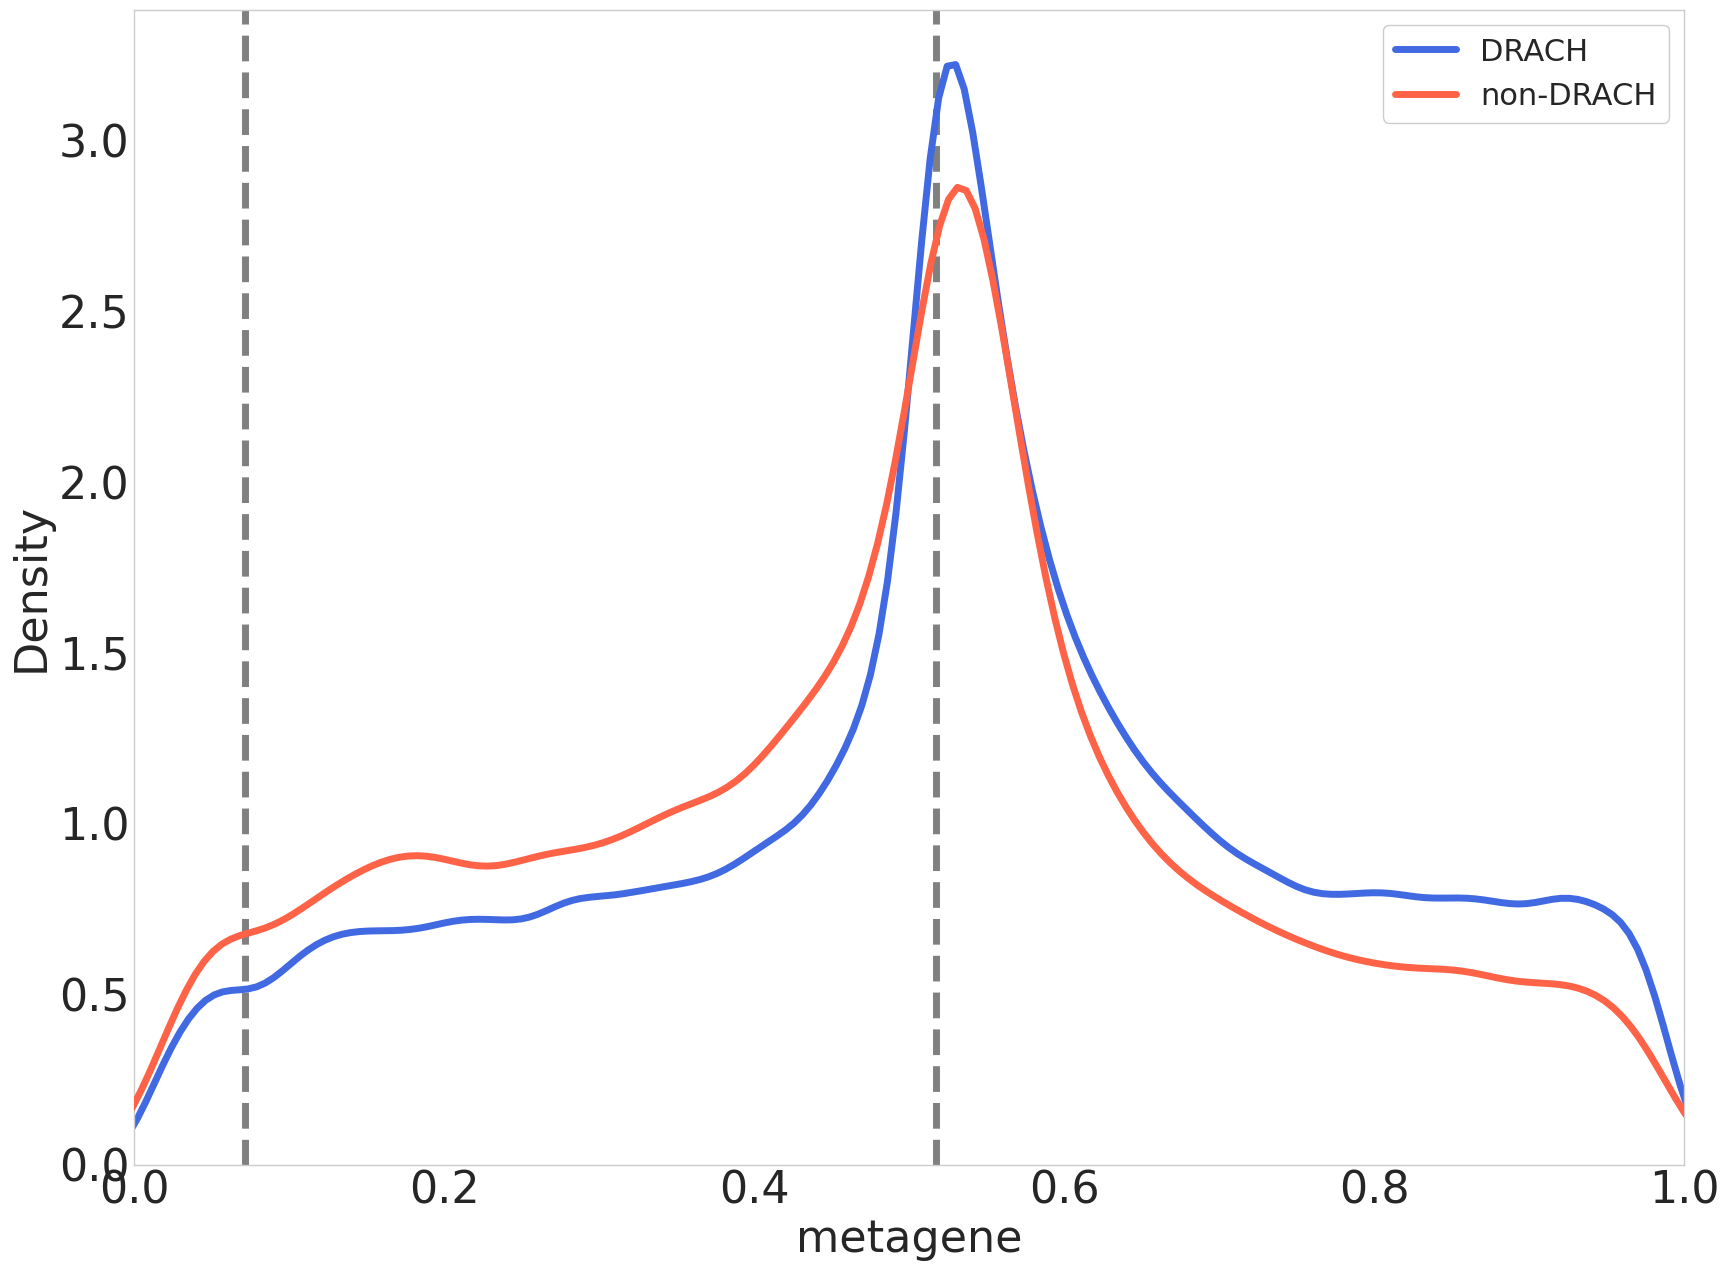

In [87]:
## Draw metagene plot
df = hek_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HEK.pdf", format="pdf")
plt.legend()
plt.show()

0.1720411330461502 0.6126933693885803


/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):
/home/sonic/baeklab/Junhak/anaconda3/envs/Hyeonseo_torch/lib/python3.9/site-packages/seaborn/_oldcore.py:1119: FutureWarning: use_inf_as_na option is deprecated and will be removed in a future version. Convert inf values to NaN before operating instead.
  with pd.option_context('mode.use_inf_as_na', True):


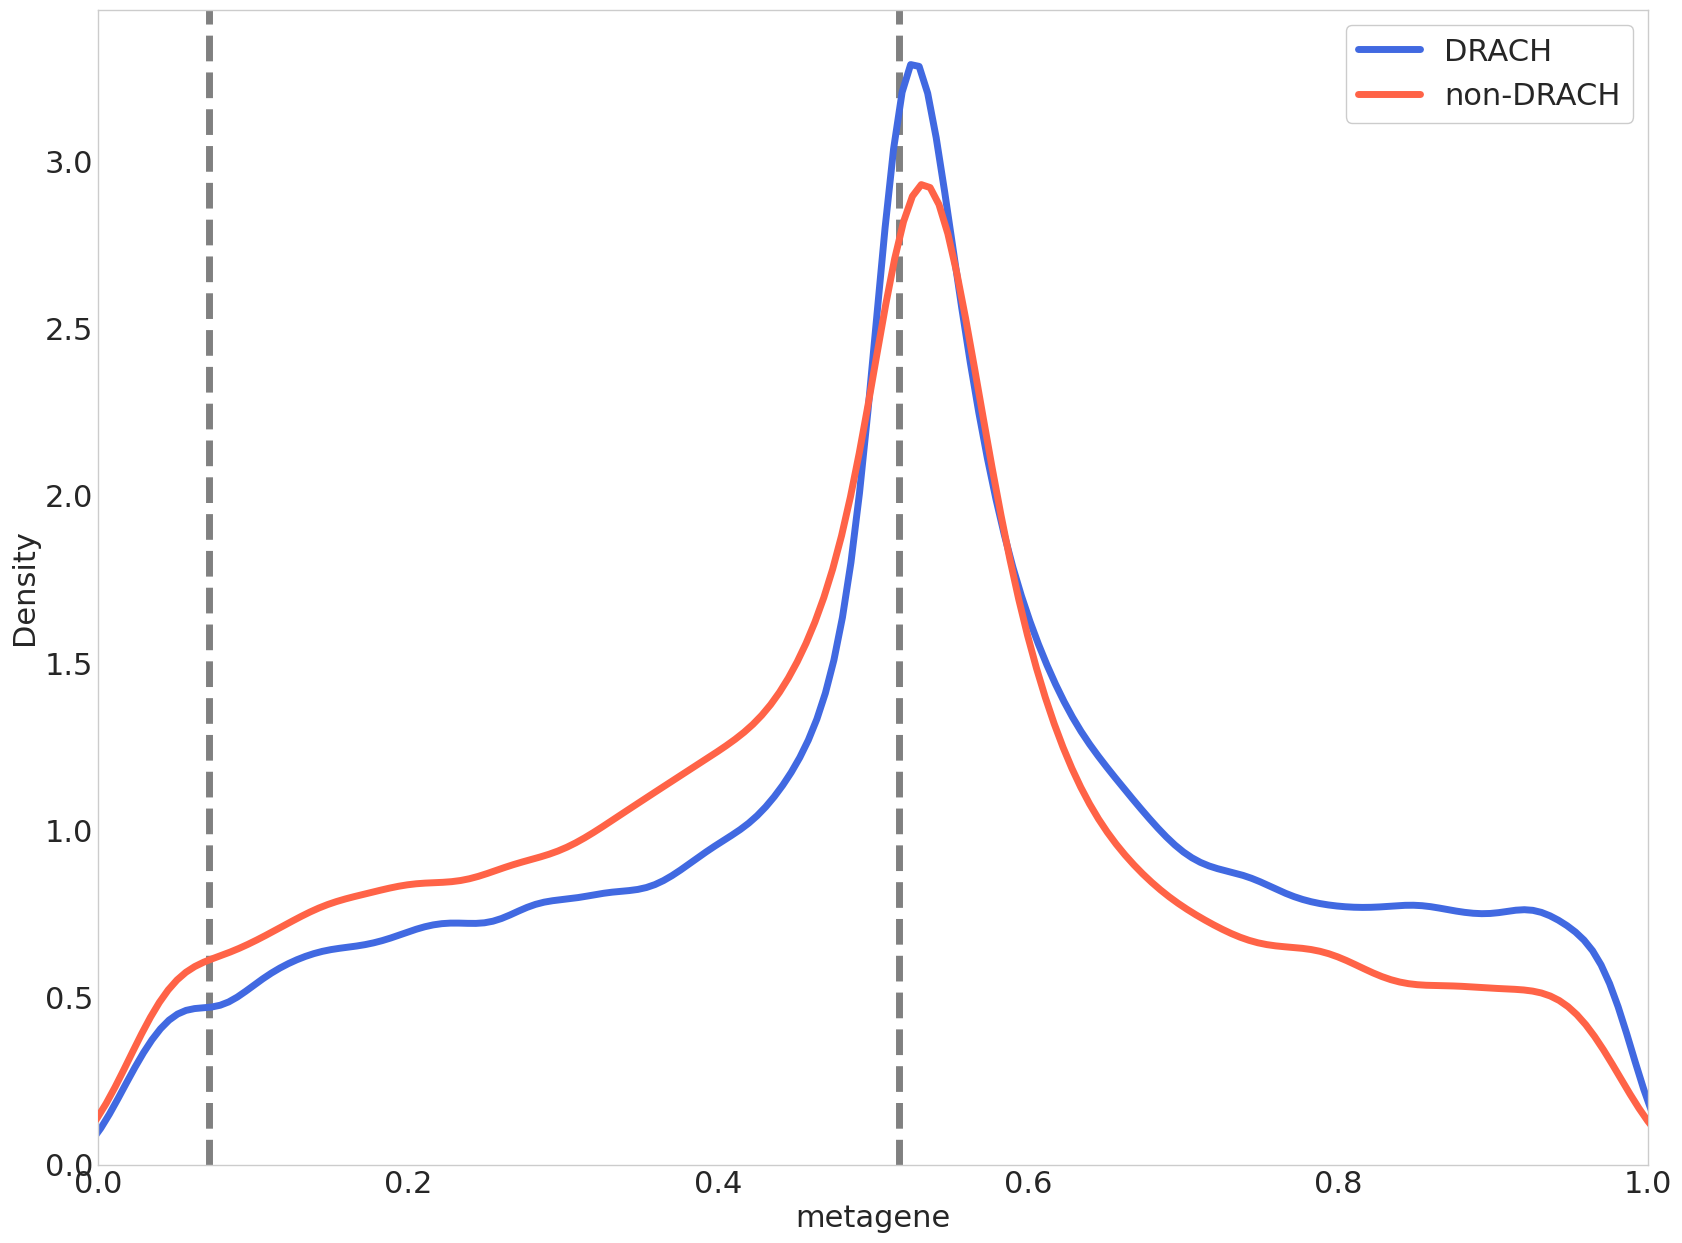

In [88]:
## Draw metagene plot
df = hela_m6a_df
fig, ax = plt.subplots(figsize=(20, 15))

plt.style.use('default')
plt.style.use('seaborn-v0_8-whitegrid')
plt.rcParams.update({'font.size': 22, 'legend.facecolor': 'white', 'legend.framealpha': 1, "legend.frameon": 1, "lines.linewidth": 5})
## Histogram style without fill.

low_cut = 0.25
high_cut = 0.75

low_cut = df["dom"].quantile(low_cut)
high_cut = df["dom"].quantile(high_cut)

print(low_cut, high_cut)

sns.kdeplot(df[df["drach"]]["metagene"], ax=ax, fill=False, color="royalblue", label="DRACH", zorder=1, bw_adjust=0.75)
sns.kdeplot(df[~df["drach"]]["metagene"], ax=ax, fill=False, color="tomato", label="non-DRACH", zorder=3, bw_adjust=0.75)

for i in range(1, 3):
    ax.axvline(np.array(preset[:i]).sum(), color="grey", linestyle="--", zorder=0)
ax.grid(False)
ax.set_xlim(0, 1)
plt.savefig("/extdata4/baeklab/Hyeonseo/m6A/poster/metagene_HeLa.pdf", format="pdf")
plt.legend()
plt.show()